#1. Contexto do problema


O cliente é um marketplace de eletrodomésticos e produtos para casa, com operação em VTEX, mensuração via Google Analytics 4 e campanhas ativas de CRM por e-mail. A empresa quer evoluir sua capacidade analítica em duas frentes de negócio: entender se os produtos destacados no banner da home estão gerando resultado e analisar o comportamento de compra por categoria para identificar oportunidades de otimização da jornada do usuário.

O principal desafio está na qualidade e integração das fontes disponíveis. Embora existam dados de transações no GA4, pedidos na VTEX, catálogo de produtos, campanhas de CRM e uma planilha manual com os produtos exibidos no banner, a mensuração do banner é incompleta: o GA4 não captura impressões nem cliques desse espaço. Além disso, a planilha do banner não contém o identificador do produto, o que exige uma etapa prévia de correspondência com o catálogo oficial.

# 2. Fontes de Dados

A análise foi construída a partir dos cinco arquivos CSV disponibilizados, cada um com um papel específico no processo:


1.   **base_produtos.csv**: catálogo completo de produtos da operação, contendo identificadores e atributos como nome, categoria, marca, preço e SKU. Essa base foi usada como referência principal para identificação dos produtos;

2.   **planilha_banner_cliente.csv**: lista manual dos produtos exibidos no banner da home durante janeiro e fevereiro de 2025. Como essa base não contém item_id, foi necessária uma etapa de correspondência com o catálogo;

3. **export_ga4_transacoes.csv**: exportação de transações do Google Analytics 4 no período analisado. Essa base foi usada como apoio para validação e leitura complementar da jornada;

4. **pedidos_vtex.csv**: base transacional da VTEX com os pedidos registrados no período. Foi tratada como a principal fonte para análise de pedidos e receita;

5. **crm_campanhas.csv**: base com dados de campanhas de e-mail marketing, incluindo envios, aberturas, cliques, conversões e receita atribuída. Foi utilizada para contextualizar o papel do CRM na performance por categoria.

# 3. Metodologia

A análise foi conduzida em quatro etapas principais: entendimento das bases, conciliação dos produtos do banner com o catálogo, reconciliação entre as fontes transacionais e consolidação das análises por produto e por categoria.

## 3.1. Auditoria inicial das bases

O primeiro passo foi inspecionar os cinco arquivos disponíveis para entender estrutura, volume, tipos de coluna, campos-chave, presença de valores nulos e possíveis inconsistências. Também foram padronizados formatos de data e nomes de colunas, quando necessário, para facilitar os cruzamentos posteriores.

### 3.1.1. Instalação de dependências

Como a etapa de conciliação entre a planilha do banner e o catálogo exige comparação aproximada de texto, foi utilizada a biblioteca `rapidfuzz`, instalada no ambiente do Colab.

In [106]:
!pip install rapidfuzz

### 3.1.2. Importação das bibliotecas

Nesta etapa, foram importadas as bibliotecas necessárias para leitura dos arquivos, tratamento e padronização textual, matching aproximado entre produtos, manipulação das bases e visualização dos resultados.

As bibliotecas utilizadas foram:

- **pandas**: leitura, tratamento e análise das tabelas;
- **numpy**: apoio a operações numéricas e condicionais;
- **re** e **unicodedata**: limpeza e padronização textual dos nomes dos produtos;
- **rapidfuzz**: matching aproximado por similaridade textual;
- **matplotlib**: construção dos gráficos utilizados na análise.

In [107]:
import pandas as pd
import numpy as np
import re
import unicodedata
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

### 3.1.3. Criação da base URL

Nesta etapa, foi definida a URL base do repositório no GitHub que contém os arquivos CSV utilizados no teste técnico. A partir desse caminho base, os datasets podem ser lidos diretamente no notebook, o que facilita a reprodutibilidade da análise e evita dependência de upload manual.

In [108]:
BASE_URL = "https://raw.githubusercontent.com/metricasboss/teste-tecnico-analista-dados/fe83122c9755d2d02b4499000698a5d541182ccf/dados"

### 3.1.4. Leitura dos 5 CSVs

In [109]:
base_produtos = pd.read_csv(f"{BASE_URL}/base_produtos.csv")
banner = pd.read_csv(f"{BASE_URL}/planilha_banner_cliente.csv")
ga4 = pd.read_csv(f"{BASE_URL}/export_ga4_transacoes.csv")
pedidos = pd.read_csv(f"{BASE_URL}/pedidos_vtex.csv")
crm = pd.read_csv(f"{BASE_URL}/crm_campanhas.csv")

### 3.1.5. Confirmação do carregamento

In [110]:
print("base_produtos:", base_produtos.shape)
print("banner:", banner.shape)
print("ga4:", ga4.shape)
print("pedidos:", pedidos.shape)
print("crm:", crm.shape)

base_produtos: (5001, 10)
banner: (31, 5)
ga4: (15000, 11)
pedidos: (16200, 15)
crm: (146, 13)


### 3.1.6. Visualização inicial das bases

Após a leitura dos arquivos, foi feita uma inspeção inicial das primeiras linhas de cada tabela. O objetivo dessa etapa é validar se o carregamento ocorreu corretamente, entender a estrutura geral das bases e identificar, de forma preliminar, os principais campos disponíveis para os cruzamentos posteriores.

In [111]:
display(base_produtos.head())
display(banner.head())
display(ga4.head())
display(pedidos.head())
display(crm.head())

,item_id,sku,nome_produto,categoria,marca,preco,url_produto,status_url,voltagem,data_cadastro
0,3179,SKU-TVA-00380,Home Theater AOC Smart 5.1 500W Prata,"TV, Áudio e Vídeo",AOC,804.83,https://www.lojaficticia.com.br/produto/home-t...,ativo,Bivolt,2024-07-28
1,2994,SKU-TVA-00195,"Smart TV Samsung EcoBubble 65"" 4K Preto","TV, Áudio e Vídeo",Samsung,2433.99,https://www.lojaficticia.com.br/produto/smart-...,ativo,110V,2024-10-06
2,2481,SKU-ELE-00682,Máquina de Lavar Samsung Evolution 10kg Prata,Eletrodomésticos,Samsung,2092.45,https://www.lojaficticia.com.br/produto/maquin...,ativo,110V,2024-02-11
3,2052,SKU-ELE-00253,Micro-ondas Electrolux Pure i9 30L Preto,Eletrodomésticos,Electrolux,996.35,https://www.lojaficticia.com.br/produto/micro-...,ativo,220V,2024-02-25
4,1621,SKU-CLI-00622,Ar Condicionado Split Philco PTV 30000 BTUs Fr...,Climatização,Philco,1369.65,https://www.lojaficticia.com.br/produto/ar-con...,ativo,220V,2024-10-21


,nome_produto,posicao_banner,data_inicio,data_fim,categoria_informada
0,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,4,15/02/2025,28/02/2025,Móveis
1,Panela Eletrica de Pressao Britania Turbo 4L Inox,5,15/01/2025,29/01/2025,Utilidades Domésticas
2,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,5,01/02/2025,08/02/2025,"TV, Áudio e Vídeo"
3,Sofa Artely Treviso 3 Lugares Cinza,5,08/02/2025,15/02/2025,Móveis
4,PURIFICADOR DE AR PHILCO ECO INVERTER HEPA ATÉ...,3,08/02/2025,22/02/2025,Climatizacao


,date,transaction_id,item_id,item_name,item_category,item_brand,quantity,item_revenue,source_medium,device_category,is_banner_product
0,20250210,T-20250210-00144,2328,Lava-Louças LG Smart,Eletrodomésticos,LG,1,3385.53,facebook / paid,desktop,0
1,20250112,T-20250112-00104,2500,Geladeira Panasonic Inverter Frost Free 431L P...,Eletrodomésticos,Panasonic,2,2691.11,google / organic,desktop,0
2,20250206,T-20250206-00045,1329,Ventilador de Torre Samsung Crystal 40cm Inox,Climatização,Samsung,1,4653.40,google / cpc,mobile,0
3,20250112,T-20250112-00023,1049,Ventilador de Torre LG Dual Inverter Voice 40c...,Climatização,LG,1,3062.72,google / organic,mobile,0
4,20250224,T-20250224-00056,1391,Cortina de Ar Samsung Bespoke 90cm Grafite,Climatização,Samsung,1,3237.56,(direct) / (none),(not set),0


,order_id_vtex,transaction_id_ga4,date,item_id,sku,nome_produto_vtex,categoria,marca,quantidade,receita_produto,frete,receita_total,forma_pagamento,status_pedido,cupom_aplicado
0,ORD-20250130-00039,T-20250130-00039,2025-01-30,1332,SKU-CLI-00333,Purificador de Ar Samsung WindFree até 50m² Prata,Climatização,Samsung,1,4534.37,0.00,4534.37,credit_card,faturado,NaN
1,ORD-20250122-00385,T-20250122-00385,2025-01-22,5263,SKU-ILU-00064,Plafon Taschibra Cristal LED 18W Redondo Cinza,Iluminação,Taschibra,1,110.78,72.81,183.59,credit_card,entregue,NaN
2,ORD-20250101-X0429,NaN,2025-01-01,3538,SKU-ESP-00139,Mesa de Ping Pong Gallant Force Oficial 25mm Inox,Esporte e Lazer,Gallant,1,1072.14,0.00,1072.14,boleto,faturado,NaN
3,ORD-20250112-00009,T-20250112-00009,2025-01-12,1057,SKU-CLI-00058,Ventilador de Coluna LG ThinQ 50cm Prata,Climatização,LG,1,4072.80,0.00,4072.80,pix,faturado,SIM
4,ORD-20250102-00202,T-20250102-00202,2025-01-02,4490,SKU-MOV-00391,"Rack para TV Caemmun Elegance até 50"" Branco",Móveis,Caemmun,1,1386.03,0.00,1386.03,credit_card,faturado,NaN


,data_envio,dia_semana,nome_campanha,tipo_campanha,categoria_foco,total_envios,total_aberturas,total_cliques,total_conversoes,receita_atribuida,taxa_abertura,taxa_clique,taxa_conversao
0,2025-01-01,Quarta,Carrinho Abandonado - Climatização - 01/01,Carrinho Abandonado,Climatização,4044,767,55,1,836.70,0.1897,0.0717,0.0182
1,2025-01-01,Quarta,Carrinho Abandonado - Eletrodomésticos - 01/01,Carrinho Abandonado,Eletrodomésticos,5622,737,29,0,0.00,0.1311,0.0393,0.0000
2,2025-01-01,Quarta,Promoção Semanal - Esporte e Lazer - 01/01,Promoção Semanal,Esporte e Lazer,13625,1643,118,1,145.55,0.1206,0.0718,0.0085
3,2025-01-01,Quarta,Carrinho Abandonado - Utilidades Domésticas - ...,Carrinho Abandonado,Utilidades Domésticas,3129,587,44,0,0.00,0.1876,0.0750,0.0000
4,2025-01-02,Quinta,"Lançamento - TV, Áudio e Vídeo - 02/01",Lançamento,"TV, Áudio e Vídeo",14892,4441,320,1,285.88,0.2982,0.0721,0.0031


### 3.1.7. Tabela-resumo das bases

Criei uma tabela-resumo das bases utilizadas no case. O objetivo é documentar, de forma organizada, o nome de cada arquivo, sua descrição, volume e papel dentro da análise.

In [112]:
bases_resumo = pd.DataFrame({
    "arquivo": [
        "base_produtos.csv",
        "planilha_banner_cliente.csv",
        "export_ga4_transacoes.csv",
        "pedidos_vtex.csv",
        "crm_campanhas.csv"
    ],
    "descricao": [
        "Catálogo completo de produtos",
        "Produtos exibidos no banner da home",
        "Transações exportadas do GA4",
        "Pedidos registrados na VTEX",
        "Campanhas de e-mail marketing"
    ],
    "linhas": [
        len(base_produtos),
        len(banner),
        len(ga4),
        len(pedidos),
        len(crm)
    ],
    "colunas": [
        base_produtos.shape[1],
        banner.shape[1],
        ga4.shape[1],
        pedidos.shape[1],
        crm.shape[1]
    ],
    "papel_na_analise": [
        "Base de referência para identificação de produtos, categorias, marcas e SKUs",
        "Base manual usada para identificar os itens destacados no banner",
        "Base de apoio para reconciliação e leitura complementar da jornada",
        "Fonte principal para análise de pedidos e receita",
        "Base complementar para entender o papel do CRM por categoria"
    ]
})

display(bases_resumo)

,arquivo,descricao,linhas,colunas,papel_na_analise
0,base_produtos.csv,Catálogo completo de produtos,5001,10,Base de referência para identificação de produ...
1,planilha_banner_cliente.csv,Produtos exibidos no banner da home,31,5,Base manual usada para identificar os itens de...
2,export_ga4_transacoes.csv,Transações exportadas do GA4,15000,11,Base de apoio para reconciliação e leitura com...
3,pedidos_vtex.csv,Pedidos registrados na VTEX,16200,15,Fonte principal para análise de pedidos e receita
4,crm_campanhas.csv,Campanhas de e-mail marketing,146,13,Base complementar para entender o papel do CRM...


### 3.1.8. Verificação de tipos e nulos

Nesta etapa, foi feita uma checagem dos tipos de dados (`dtypes`) e da quantidade de valores nulos por coluna.

O objetivo é identificar possíveis problemas de consistência antes dos cruzamentos, como:
- colunas com tipo inadequado para a análise;
- campos-chave com ausência de preenchimento;
- sinais de necessidade de tratamento adicional nas etapas seguintes.

In [113]:
dfs = {
    "base_produtos": base_produtos,
    "banner": banner,
    "ga4": ga4,
    "pedidos": pedidos,
    "crm": crm
}

for nome, df in dfs.items():
    print(f"\n### {nome.upper()} - TIPOS E NULOS")
    print(df.dtypes)
    print("\nNulos por coluna:")
    print(df.isna().sum().sort_values(ascending=False))


### BASE_PRODUTOS - TIPOS E NULOS
item_id            int64
sku               object
nome_produto      object
categoria         object
marca             object
preco            float64
url_produto       object
status_url        object
voltagem          object
data_cadastro     object
dtype: object

Nulos por coluna:
item_id          0
sku              0
nome_produto     0
categoria        0
marca            0
preco            0
url_produto      0
status_url       0
voltagem         0
data_cadastro    0
dtype: int64

### BANNER - TIPOS E NULOS
nome_produto           object
posicao_banner          int64
data_inicio            object
data_fim               object
categoria_informada    object
dtype: object

Nulos por coluna:
categoria_informada    4
nome_produto           0
posicao_banner         0
data_inicio            0
data_fim               0
dtype: int64

### GA4 - TIPOS E NULOS
date                   int64
transaction_id        object
item_id                int64
item_name         

### 3.1.9. Verificação de duplicidades

Além da inspeção de tipos e valores nulos, também foi feita uma checagem simples de linhas duplicadas em cada base. Essa etapa ajuda a identificar possíveis problemas de qualidade dos dados que poderiam distorcer contagens, somas ou cruzamentos ao longo da análise.

In [114]:
for nome, df in dfs.items():
    print(f"{nome}: {df.duplicated().sum()} linhas duplicadas")

base_produtos: 0 linhas duplicadas
banner: 0 linhas duplicadas
ga4: 0 linhas duplicadas
pedidos: 0 linhas duplicadas
crm: 0 linhas duplicadas


### 3.1.10. Padronização de datas

Como a análise depende de comparações temporais, especialmente nas etapas de exposição do banner, pedidos da VTEX e campanhas de CRM, foi necessário padronizar os campos de data.

In [115]:
pedidos = pedidos.rename(columns={"date": "data_pedido"})

if "data_inicio" in banner.columns:
    banner["data_inicio"] = pd.to_datetime(
        banner["data_inicio"],
        format="%d/%m/%Y",
        errors="coerce"
    )

if "data_fim" in banner.columns:
    banner["data_fim"] = pd.to_datetime(
        banner["data_fim"],
        format="%d/%m/%Y",
        errors="coerce"
    )

if "data_pedido" in pedidos.columns:
    pedidos["data_pedido"] = pd.to_datetime(
        pedidos["data_pedido"],
        format="%Y-%m-%d",
        errors="coerce"
    )

if "data_envio" in crm.columns:
    crm["data_envio"] = pd.to_datetime(
        crm["data_envio"],
        errors="coerce",
        dayfirst=True
    )

## 3.2. Conciliação da planilha do banner com o catálogo

Como a planilha do banner não continha `item_id`, foi necessário criar uma etapa intermediária de correspondência com o catálogo oficial de produtos.

Esse processo foi feito em três fases:

1. **padronização textual**, com limpeza e normalização dos nomes dos produtos;
2. **matching exato**, para identificar correspondências diretas entre banner e catálogo;
3. **matching aproximado e revisão manual**, para recuperar casos plausíveis que não haviam sido conciliados automaticamente.




### 3.2.1. Padronização textual dos nomes dos produtos

O primeiro passo da conciliação entre banner e catálogo foi a criação de uma função de normalização textual. O objetivo dessa etapa é reduzir diferenças de escrita que poderiam impedir o matching entre as bases.

A função aplica os seguintes tratamentos:
- converte o texto para minúsculas;
- remove espaços excedentes;
- elimina acentos;
- remove caracteres especiais e pontuação;
- e padroniza múltiplos espaços em um único espaço.

Com isso, nomes como “Máquina de Lavar” e “maquina de lavar” passam a ter uma representação comparável, aumentando a chance de correspondência correta entre as bases.

In [116]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

### 3.2.2. Aplicação da normalização textual

In [117]:
banner["nome_produto_limpo"] = banner["nome_produto"].apply(normalizar_texto)
base_produtos["nome_produto_limpo"] = base_produtos["nome_produto"].apply(normalizar_texto)

display(banner[["nome_produto", "nome_produto_limpo"]].head())
display(base_produtos[["nome_produto", "nome_produto_limpo"]].head())

,nome_produto,nome_produto_limpo
0,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,mesa de jantar linea brasil adonai 4 cadeiras ...
1,Panela Eletrica de Pressao Britania Turbo 4L Inox,panela eletrica de pressao britania turbo 4l inox
2,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,fone de ouvido philco hit bluetooth in ear gra...
3,Sofa Artely Treviso 3 Lugares Cinza,sofa artely treviso 3 lugares cinza
4,PURIFICADOR DE AR PHILCO ECO INVERTER HEPA ATÉ...,purificador de ar philco eco inverter hepa ate...


,nome_produto,nome_produto_limpo
0,Home Theater AOC Smart 5.1 500W Prata,home theater aoc smart 5 1 500w prata
1,"Smart TV Samsung EcoBubble 65"" 4K Preto",smart tv samsung ecobubble 65 4k preto
2,Máquina de Lavar Samsung Evolution 10kg Prata,maquina de lavar samsung evolution 10kg prata
3,Micro-ondas Electrolux Pure i9 30L Preto,micro ondas electrolux pure i9 30l preto
4,Ar Condicionado Split Philco PTV 30000 BTUs Fr...,ar condicionado split philco ptv 30000 btus fr...


### 3.2.3. Matching exato entre banner e catálogo

Com os nomes já padronizados, foi realizado o primeiro estágio de conciliação: o **matching exato** entre a planilha do banner e o catálogo oficial de produtos.

Nessa etapa, a junção foi feita pela coluna `nome_produto_limpo`, buscando identificar correspondências diretas entre as duas bases. Quando o `item_id` do catálogo foi encontrado, o match foi classificado como `exact` e recebeu score 100, por se tratar de uma correspondência exata após a normalização textual.

Ao final, foram comparados:
- o total de linhas da planilha do banner;
- e a quantidade de linhas que conseguiram correspondência direta com o catálogo.

In [118]:
match_exato = banner.merge(
    base_produtos,
    on="nome_produto_limpo",
    how="left",
    suffixes=("_banner", "_catalogo")
)

match_exato["match_type"] = np.where(match_exato["item_id"].notna(), "exact", None)
match_exato["match_score"] = np.where(match_exato["item_id"].notna(), 100, None)

print("Total de produtos no banner:", len(banner))
print("Matches exatos:", match_exato["item_id"].notna().sum())

Total de produtos no banner: 31
Matches exatos: 20


### 3.2.4. Separação dos casos sem match exato

In [119]:
nao_match = match_exato[match_exato["item_id"].isna()].copy()

colunas_preview = [c for c in ["nome_produto_banner", "nome_produto", "nome_produto_limpo"] if c in nao_match.columns]
display(nao_match[colunas_preview].head(11))
print("Sem match exato:", len(nao_match))

,nome_produto_banner,nome_produto_limpo
5,Lavar de Máquina Arno Deluxe 8kg Preto,lavar de maquina arno deluxe 8kg preto
7,Grill Elet. Mallory Delfino Churrasqueira Elet...,grill elet mallory delfino churrasqueira elet ...
15,Sofá Caemmun Lord Canto 5,sofa caemmun lord canto 5
18,GELADEIRA ATIVE! BRASTEMP DUPLEX 362L,geladeira ative brastemp duplex 362l
22,Projetor Digital Samsung Inverter Full HD 3500...,projetor digital samsung inverter full hd 3500...
24,Ventilador Portátil Arno Supreme Ultra Silence...,ventilador portatil arno supreme ultra silence...
25,Eletrica Esteira Gallant Combat ate,eletrica esteira gallant combat ate
26,Climatizador de Ar LG NeoChef,climatizador de ar lg neochef
27,Climatizador Ar de Elgin,climatizador ar de elgin
29,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,de mesa ping pong gallant extreme mdf 18mm dob...


Sem match exato: 11


### 3.2.5. Preparação do matching aproximado para os casos sem correspondência exata

Para os produtos que não tiveram correspondência no matching exato, foi preparada uma segunda etapa de conciliação baseada em similaridade textual.

Primeiro, foi criada uma lista com os nomes padronizados do catálogo (`catalogo_nomes`), que servirá como conjunto de comparação. Em seguida, foi definida a função `buscar_melhor_match`, responsável por procurar, para cada produto sem match exato, o nome mais parecido dentro do catálogo.

A função utiliza o critério `token_sort_ratio`, que compara os textos considerando similaridade entre palavras, e adota um **score mínimo de 85** para evitar correspondências pouco confiáveis.

In [120]:
catalogo_nomes = base_produtos["nome_produto_limpo"].dropna().unique().tolist()

def buscar_melhor_match(nome, escolhas, score_min=85):
    resultado = process.extractOne(nome, escolhas, scorer=fuzz.token_sort_ratio)
    if resultado:
        melhor_nome, score, _ = resultado
        if score >= score_min:
            return melhor_nome, score
    return None, None

### 3.2.6. Aplicação do matching aproximado

Após definir a lógica de similaridade, o matching aproximado foi aplicado aos produtos que permaneceram sem correspondência no estágio anterior. Para cada linha sem match exato, foram registrados:

- o **melhor nome candidato** encontrado no catálogo (`melhor_nome_limpo`);
- e o respectivo **score de similaridade** (`match_score`).

Em seguida, foi exibida uma amostra dos resultados para validação inicial, permitindo verificar se os candidatos encontrados faziam sentido antes da consolidação final.

In [121]:
nao_match[["melhor_nome_limpo", "match_score"]] = nao_match["nome_produto_limpo"].apply(
    lambda x: pd.Series(buscar_melhor_match(x, catalogo_nomes, score_min=85))
)

col_nome_banner = "nome_produto_banner" if "nome_produto_banner" in nao_match.columns else "nome_produto"

display(
    nao_match[[col_nome_banner, "nome_produto_limpo", "melhor_nome_limpo", "match_score"]].head(11)
)

,nome_produto_banner,nome_produto_limpo,melhor_nome_limpo,match_score
5,Lavar de Máquina Arno Deluxe 8kg Preto,lavar de maquina arno deluxe 8kg preto,maquina de lavar arno deluxe 8kg preto,100.000000
7,Grill Elet. Mallory Delfino Churrasqueira Elet...,grill elet mallory delfino churrasqueira elet ...,grill eletrico mallory delfino churrasqueira e...,93.442623
15,Sofá Caemmun Lord Canto 5,sofa caemmun lord canto 5,None,NaN
18,GELADEIRA ATIVE! BRASTEMP DUPLEX 362L,geladeira ative brastemp duplex 362l,geladeira brastemp ative duplex 362l branco,91.139241
22,Projetor Digital Samsung Inverter Full HD 3500...,projetor digital samsung inverter full hd 3500...,projetor samsung digital inverter full hd 3500...,100.000000
24,Ventilador Portátil Arno Supreme Ultra Silence...,ventilador portatil arno supreme ultra silence...,None,NaN
25,Eletrica Esteira Gallant Combat ate,eletrica esteira gallant combat ate,esteira eletrica gallant combat ate 12km h,90.909091
26,Climatizador de Ar LG NeoChef,climatizador de ar lg neochef,climatizador de ar lg neochef 7l,95.081967
27,Climatizador Ar de Elgin,climatizador ar de elgin,None,NaN
29,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,de mesa ping pong gallant extreme mdf 18mm dob...,mesa de ping pong gallant extreme mdf 18mm dob...,100.000000


### 3.2.7. Enriquecimento dos matches aproximados com dados do catálogo

Depois de identificar o melhor nome candidato para cada produto sem match exato, o próximo passo foi trazer os atributos completos do catálogo correspondentes a esses candidatos.

Para isso, a base dos casos sem correspondência exata foi cruzada novamente com o catálogo, desta vez usando:
- `melhor_nome_limpo` como chave da esquerda;
- `nome_produto_limpo_catalogo` como chave da direita.

Esse merge permitiu recuperar informações como `item_id`, `sku`, categoria, marca e preço dos produtos encontrados via matching aproximado, viabilizando a etapa de validação final e posterior consolidação do matching.

In [122]:
fuzzy_match = nao_match.merge(
    base_produtos.add_suffix("_catalogo"),
    left_on="melhor_nome_limpo",
    right_on="nome_produto_limpo_catalogo",
    how="left"
)

display(fuzzy_match.head(11))

,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,nome_produto_limpo,item_id,sku,nome_produto_catalogo_x,categoria,...,sku_catalogo,nome_produto_catalogo_y,categoria_catalogo,marca_catalogo,preco_catalogo,url_produto_catalogo,status_url_catalogo,voltagem_catalogo,data_cadastro_catalogo,nome_produto_limpo_catalogo
0,Lavar de Máquina Arno Deluxe 8kg Preto,3,2025-02-01,2025-02-15,Eletrodomesticos,lavar de maquina arno deluxe 8kg preto,NaN,NaN,NaN,NaN,...,SKU-ELE-00986,Máquina de Lavar Arno Deluxe 8kg Preto,Eletrodomésticos,Arno,321.57,https://www.lojaficticia.com.br/produto/maquin...,ativo,110V,2024-07-29,maquina de lavar arno deluxe 8kg preto
1,Grill Elet. Mallory Delfino Churrasqueira Elet...,1,2025-02-22,2025-02-28,Utilidades Domésticas,grill elet mallory delfino churrasqueira elet ...,NaN,NaN,NaN,NaN,...,SKU-UTD-00434,Grill Elétrico Mallory Delfino Churrasqueira E...,Utilidades Domésticas,Mallory,93.80,https://www.lojaficticia.com.br/produto/grill-...,ativo,220V,2024-07-16,grill eletrico mallory delfino churrasqueira e...
2,Sofá Caemmun Lord Canto 5,4,2025-02-22,2025-02-28,Móveis,sofa caemmun lord canto 5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GELADEIRA ATIVE! BRASTEMP DUPLEX 362L,5,2025-01-15,2025-01-22,Eletrodomésticos,geladeira ative brastemp duplex 362l,NaN,NaN,NaN,NaN,...,SKU-ELE-00059,Geladeira Brastemp Ative! Duplex 362L Branco,Eletrodomésticos,Brastemp,1590.53,https://www.lojaficticia.com.br/produto/gelade...,ativo,110V,2024-03-07,geladeira brastemp ative duplex 362l branco
4,Projetor Digital Samsung Inverter Full HD 3500...,2,2025-02-01,2025-02-22,"TV, Áudio e Vídeo",projetor digital samsung inverter full hd 3500...,NaN,NaN,NaN,NaN,...,SKU-TVA-00185,Projetor Samsung Digital Inverter Full HD 3500...,"TV, Áudio e Vídeo",Samsung,4126.70,https://www.lojaficticia.com.br/produto/projet...,ativo,220V,2024-09-15,projetor samsung digital inverter full hd 3500...
5,Ventilador Portátil Arno Supreme Ultra Silence...,2,2025-01-15,2025-01-28,Climatização,ventilador portatil arno supreme ultra silence...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Eletrica Esteira Gallant Combat ate,1,2025-01-08,2025-01-29,Esporte e Lazer,eletrica esteira gallant combat ate,NaN,NaN,NaN,NaN,...,SKU-ESP-00269,Esteira Elétrica Gallant Combat até 12km/h,Esporte e Lazer,Gallant,1029.41,https://www.lojaficticia.com.br/produto/esteir...,ativo,220V,2024-11-20,esteira eletrica gallant combat ate 12km h
7,Climatizador de Ar LG NeoChef,5,2025-02-01,2025-02-08,NaN,climatizador de ar lg neochef,NaN,NaN,NaN,NaN,...,SKU-CLI-00158,Climatizador de Ar LG NeoChef 7L,Climatização,LG,3403.68,https://www.lojaficticia.com.br/produto/climat...,ativo,220V,2024-08-26,climatizador de ar lg neochef 7l
8,Climatizador Ar de Elgin,4,2025-01-01,2025-01-22,Climatização,climatizador ar de elgin,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,2,2025-01-15,2025-01-22,Esporte e Lazer,de mesa ping pong gallant extreme mdf 18mm dob...,NaN,NaN,NaN,NaN,...,SKU-ESP-00273,Mesa de Ping Pong Gallant Extreme MDF 18mm Dob...,Esporte e Lazer,Gallant,873.64,https://www.lojaficticia.com.br/produto/mesa-d...,ativo,Bivolt,2024-04-05,mesa de ping pong gallant extreme mdf 18mm dob...


### 3.2.8. Classificação dos resultados do matching aproximado

Após o enriquecimento com os dados do catálogo, cada linha do matching aproximado foi classificada em uma de duas situações:

- **`fuzzy`**: quando foi encontrada uma correspondência válida no catálogo, ou seja, quando `item_id_catalogo` estava preenchido;
- **`unmatched`**: quando não foi encontrada correspondência confiável, mantendo a linha como não conciliada.

A visualização final dessa etapa permite revisar, para cada produto do banner, o nome candidato encontrado, o score de similaridade e o status da correspondência.

In [123]:
col_nome_banner = "nome_produto_banner" if "nome_produto_banner" in fuzzy_match.columns else "nome_produto"

fuzzy_match["match_type"] = np.where(
    fuzzy_match["item_id_catalogo"].notna(),
    "fuzzy",
    "unmatched"
)

display(
    fuzzy_match[[col_nome_banner, "melhor_nome_limpo", "match_score", "item_id_catalogo", "match_type"]]
)

,nome_produto_banner,melhor_nome_limpo,match_score,item_id_catalogo,match_type
0,Lavar de Máquina Arno Deluxe 8kg Preto,maquina de lavar arno deluxe 8kg preto,100.000000,2785.0,fuzzy
1,Grill Elet. Mallory Delfino Churrasqueira Elet...,grill eletrico mallory delfino churrasqueira e...,93.442623,5133.0,fuzzy
2,Sofá Caemmun Lord Canto 5,None,NaN,NaN,unmatched
3,GELADEIRA ATIVE! BRASTEMP DUPLEX 362L,geladeira brastemp ative duplex 362l branco,91.139241,1858.0,fuzzy
4,Projetor Digital Samsung Inverter Full HD 3500...,projetor samsung digital inverter full hd 3500...,100.000000,2984.0,fuzzy
5,Ventilador Portátil Arno Supreme Ultra Silence...,None,NaN,NaN,unmatched
6,Eletrica Esteira Gallant Combat ate,esteira eletrica gallant combat ate 12km h,90.909091,3668.0,fuzzy
7,Climatizador de Ar LG NeoChef,climatizador de ar lg neochef 7l,95.081967,1157.0,fuzzy
8,Climatizador Ar de Elgin,None,NaN,NaN,unmatched
9,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,mesa de ping pong gallant extreme mdf 18mm dob...,100.000000,3672.0,fuzzy


### 3.2.9. Seleção dos matches aproximados aceitos

Após a classificação dos resultados do matching aproximado, foram mantidas apenas as linhas marcadas como `fuzzy`, ou seja, aquelas que encontraram uma correspondência plausível com o catálogo.

Essa filtragem gera a base final dos **matches aproximados aceitos**, que será posteriormente combinada aos matches exatos e aos ajustes manuais para compor a tabela consolidada de produtos do banner conciliados com o catálogo.

In [124]:
fuzzy_final = fuzzy_match[fuzzy_match["match_type"] == "fuzzy"].copy()

print("Fuzzy matches aceitos:", len(fuzzy_final))
display(
    fuzzy_final[[col_nome_banner, "nome_produto_catalogo_y", "match_score", "match_type"]]
)

Fuzzy matches aceitos: 8


,nome_produto_banner,nome_produto_catalogo_y,match_score,match_type
0,Lavar de Máquina Arno Deluxe 8kg Preto,Máquina de Lavar Arno Deluxe 8kg Preto,100.000000,fuzzy
1,Grill Elet. Mallory Delfino Churrasqueira Elet...,Grill Elétrico Mallory Delfino Churrasqueira E...,93.442623,fuzzy
3,GELADEIRA ATIVE! BRASTEMP DUPLEX 362L,Geladeira Brastemp Ative! Duplex 362L Branco,91.139241,fuzzy
4,Projetor Digital Samsung Inverter Full HD 3500...,Projetor Samsung Digital Inverter Full HD 3500...,100.000000,fuzzy
6,Eletrica Esteira Gallant Combat ate,Esteira Elétrica Gallant Combat até 12km/h,90.909091,fuzzy
7,Climatizador de Ar LG NeoChef,Climatizador de Ar LG NeoChef 7L,95.081967,fuzzy
9,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,Mesa de Ping Pong Gallant Extreme MDF 18mm Dob...,100.000000,fuzzy
10,DE CAIXA SOM BLUETOOTH PHILIPS HUE 100W PARTY ...,Caixa de Som Bluetooth Philips Hue 100W Party ...,100.000000,fuzzy


### 3.2.10. Consolidação dos grupos conciliados automaticamente

Neste ponto, os resultados do processo de matching foram separados em dois grupos principais:

- **matches exatos**, obtidos por correspondência direta entre os nomes padronizados;
- **matches aproximados aceitos**, obtidos por similaridade textual e considerados plausíveis após revisão.

A contagem desses dois grupos permite acompanhar, de forma transparente, quanto da planilha do banner já foi conciliado automaticamente antes da etapa de ajuste manual.

In [125]:
exact_final = match_exato[match_exato["item_id"].notna()].copy()

print("Matches exatos:", len(exact_final))
print("Matches fuzzy aceitos:", len(fuzzy_final))

Matches exatos: 20
Matches fuzzy aceitos: 8


Padronização das colunas dos matches exatos e aproximados



Antes de unir os resultados em uma única base final, foi necessário padronizar a estrutura dos dois grupos conciliados automaticamente.

Nesta etapa:
- os **matches exatos** tiveram seus campos principais organizados em colunas finais, como `item_id_final`, `nome_produto_catalog_final` e `categoria_final`;
- os **matches aproximados aceitos** passaram pelo mesmo processo, utilizando os campos equivalentes trazidos do catálogo na etapa de fuzzy matching.

Essa padronização garante que os dois conjuntos possam ser combinados de forma consistente na base final de produtos conciliados do banner.

In [126]:
# Exatos
exact_final_out = exact_final.copy()
exact_final_out["item_id_final"] = exact_final_out["item_id"]
exact_final_out["nome_produto_catalog_final"] = exact_final_out["nome_produto_catalogo"]
exact_final_out["categoria_final"] = exact_final_out["categoria"]

# Fuzzy
fuzzy_final_out = fuzzy_final.copy()
fuzzy_final_out["item_id_final"] = fuzzy_final_out["item_id_catalogo"]
fuzzy_final_out["nome_produto_catalog_final"] = fuzzy_final_out["nome_produto_catalogo_y"]
fuzzy_final_out["categoria_final"] = fuzzy_final_out["categoria_catalogo"]

### 3.2.11. Consolidação inicial da base de produtos conciliados

Após a padronização das colunas dos matches exatos e aproximados, os dois conjuntos foram unidos em uma única base chamada `banner_matching`.

Essa base representa a consolidação inicial dos produtos do banner que conseguiram ser conciliados automaticamente com o catálogo, servindo como ponto de partida para a etapa final de ajuste manual e para os cruzamentos posteriores com a base transacional da VTEX.

In [127]:
banner_matching = pd.concat(
    [exact_final_out, fuzzy_final_out],
    ignore_index=True,
    sort=False
)

print("Linhas no banner_matching:", len(banner_matching))
display(banner_matching.head())

Linhas no banner_matching: 28


,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,nome_produto_limpo,item_id,sku,nome_produto_catalogo,categoria,...,sku_catalogo,nome_produto_catalogo_y,categoria_catalogo,marca_catalogo,preco_catalogo,url_produto_catalogo,status_url_catalogo,voltagem_catalogo,data_cadastro_catalogo,nome_produto_limpo_catalogo
0,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,4,2025-02-15,2025-02-28,Móveis,mesa de jantar linea brasil adonai 4 cadeiras ...,4267.0,SKU-MOV-00168,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,Móveis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panela Eletrica de Pressao Britania Turbo 4L Inox,5,2025-01-15,2025-01-29,Utilidades Domésticas,panela eletrica de pressao britania turbo 4l inox,4891.0,SKU-UTD-00192,Panela Elétrica de Pressão Britânia Turbo 4L Inox,Utilidades Domésticas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,5,2025-02-01,2025-02-08,"TV, Áudio e Vídeo",fone de ouvido philco hit bluetooth in ear gra...,2808.0,SKU-TVA-00009,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,"TV, Áudio e Vídeo",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sofa Artely Treviso 3 Lugares Cinza,5,2025-02-08,2025-02-15,Móveis,sofa artely treviso 3 lugares cinza,4397.0,SKU-MOV-00298,Sofá Artely Treviso 3 Lugares Cinza,Móveis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PURIFICADOR DE AR PHILCO ECO INVERTER HEPA ATÉ...,3,2025-02-08,2025-02-22,Climatizacao,purificador de ar philco eco inverter hepa ate...,1605.0,SKU-CLI-00606,Purificador de Ar Philco Eco Inverter HEPA até...,Climatização,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2.12. Seleção das colunas finais da base conciliada

Depois da consolidação inicial, foi feita uma seleção das colunas mais relevantes para compor a versão final da tabela de matching. O objetivo dessa etapa é deixar a base mais limpa, legível e adequada para uso nas próximas análises.

Além da seleção das colunas principais, foi criada a variável `matched = True` para sinalizar que essas linhas representam produtos do banner que conseguiram ser conciliados com sucesso com o catálogo.

In [128]:
colunas_final = [
    c for c in [
        "nome_produto_banner",
        "posicao_banner",
        "data_inicio",
        "data_fim",
        "categoria_informada",
        "item_id_final",
        "nome_produto_catalog_final",
        "categoria_final",
        "match_type",
        "match_score"
    ] if c in banner_matching.columns
]

banner_matching = banner_matching[colunas_final].copy()
banner_matching["matched"] = True

display(banner_matching.head(10))
print("Linhas finais:", len(banner_matching))

,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,item_id_final,nome_produto_catalog_final,categoria_final,match_type,match_score,matched
0,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,4,2025-02-15,2025-02-28,Móveis,4267.0,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,Móveis,exact,100,True
1,Panela Eletrica de Pressao Britania Turbo 4L Inox,5,2025-01-15,2025-01-29,Utilidades Domésticas,4891.0,Panela Elétrica de Pressão Britânia Turbo 4L Inox,Utilidades Domésticas,exact,100,True
2,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,5,2025-02-01,2025-02-08,"TV, Áudio e Vídeo",2808.0,Fone de Ouvido Philco Hit Bluetooth In-Ear Gra...,"TV, Áudio e Vídeo",exact,100,True
3,Sofa Artely Treviso 3 Lugares Cinza,5,2025-02-08,2025-02-15,Móveis,4397.0,Sofá Artely Treviso 3 Lugares Cinza,Móveis,exact,100,True
4,PURIFICADOR DE AR PHILCO ECO INVERTER HEPA ATÉ...,3,2025-02-08,2025-02-22,Climatizacao,1605.0,Purificador de Ar Philco Eco Inverter HEPA até...,Climatização,exact,100,True
5,Piscina Inflavel Gallant Extreme 5000L Estrutu...,3,2025-02-08,2025-02-22,Esporte e Lazer,3794.0,Piscina Inflável Gallant Extreme 5000L Estrutu...,Esporte e Lazer,exact,100,True
6,VENTILADOR DE COLUNA LG THINQ 60CM TURBO PRETO,1,2025-02-01,2025-02-15,Climatizacao,1252.0,Ventilador de Coluna LG ThinQ 60cm Turbo Preto,Climatização,exact,100,True
7,Piscina Inflavel Gallant Force 2000L,5,2025-01-01,2025-01-08,Esporte e Lazer,3509.0,Piscina Inflável Gallant Force 2000L,Esporte e Lazer,exact,100,True
8,Freezer Vertical Brastemp Gourmand 142L,4,2025-02-08,2025-02-15,NaN,1807.0,Freezer Vertical Brastemp Gourmand 142L,Eletrodomésticos,exact,100,True
9,AQUECEDOR ELÉTRICO MIDEA XTREME SAVE 2000W GRA...,5,2025-02-08,2025-02-22,NaN,1414.0,Aquecedor Elétrico Midea Xtreme Save 2000W Gra...,Climatização,exact,100,True


Linhas finais: 28


### 3.2.13. Identificação dos produtos sem correspondência confiável

Além da base conciliada, foi criada uma tabela separada com os casos que permaneceram sem correspondência confiável após o matching aproximado. Essas linhas foram classificadas como `unmatched` e mantidas em uma base específica para garantir transparência metodológica.

A seleção das colunas finais dessa tabela tem como objetivo documentar claramente:
- qual produto do banner ficou sem conciliação;
- qual era seu nome padronizado;
- qual foi o melhor candidato encontrado, quando existiu;
- e qual score de similaridade foi obtido.

Esses casos não foram utilizados nas análises que dependiam de vínculo direto com o catálogo e com a base transacional.

In [129]:
unmatched_final = fuzzy_match[fuzzy_match["match_type"] == "unmatched"].copy()

colunas_unmatched = [
    c for c in [
        "nome_produto_banner",
        "posicao_banner",
        "data_inicio",
        "data_fim",
        "categoria_informada",
        "nome_produto_limpo",
        "melhor_nome_limpo",
        "match_score",
        "match_type"
    ] if c in unmatched_final.columns
]

unmatched_final = unmatched_final[colunas_unmatched].copy()

display(unmatched_final)
print("Produtos sem match:", len(unmatched_final))

,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,nome_produto_limpo,melhor_nome_limpo,match_score,match_type
2,Sofá Caemmun Lord Canto 5,4,2025-02-22,2025-02-28,Móveis,sofa caemmun lord canto 5,None,NaN,unmatched
5,Ventilador Portátil Arno Supreme Ultra Silence...,2,2025-01-15,2025-01-28,Climatização,ventilador portatil arno supreme ultra silence...,None,NaN,unmatched
8,Climatizador Ar de Elgin,4,2025-01-01,2025-01-22,Climatização,climatizador ar de elgin,None,NaN,unmatched


Produtos sem match: 3


### 3.2.14. Revisão manual complementar dos casos sem match

Após o matching exato e o matching aproximado, três produtos ainda permaneceram sem correspondência confiável. Para esses casos, foi feita uma busca manual no catálogo utilizando partes relevantes do nome padronizado, com o objetivo de identificar correspondências plausíveis que não haviam sido capturadas automaticamente.

In [130]:
# Produto localizado

base_produtos[
    base_produtos["nome_produto_limpo"].str.contains("sofa caemmun lord canto 5", na=False)
][["item_id", "sku", "nome_produto", "categoria", "marca", "preco", "nome_produto_limpo"]]

,item_id,sku,nome_produto,categoria,marca,preco,nome_produto_limpo
2329,4504,SKU-MOV-00405,Sofá Caemmun Lord Canto 5 Lugares Grafite,Móveis,Caemmun,709.32,sofa caemmun lord canto 5 lugares grafite


In [131]:
# Produto não encontrado. Utilizei várias combinações de termos, além de "supreme"

base_produtos[
    base_produtos["nome_produto_limpo"].str.contains("supreme", na=False)
][["item_id", "sku", "nome_produto", "categoria", "marca", "preco", "nome_produto_limpo"]]

,item_id,sku,nome_produto,categoria,marca,preco,nome_produto_limpo


In [132]:
# O nome é genérico demais para afirmarmos de qual produto se trata

base_produtos[
    base_produtos["nome_produto_limpo"].str.contains("climatizador de ar elgin", na=False)
][["item_id", "sku", "nome_produto", "categoria", "marca", "preco", "nome_produto_limpo"]]

,item_id,sku,nome_produto,categoria,marca,preco,nome_produto_limpo
668,1540,SKU-CLI-00541,Climatizador de Ar Elgin Eco Plus 7L Preto,Climatização,Elgin,2660.05,climatizador de ar elgin eco plus 7l preto
2336,1544,SKU-CLI-00545,Climatizador de Ar Elgin Eco 15L Grafite,Climatização,Elgin,3431.54,climatizador de ar elgin eco 15l grafite
2756,1512,SKU-CLI-00513,Climatizador de Ar Elgin Eco Plus 15L,Climatização,Elgin,2722.31,climatizador de ar elgin eco plus 15l
3472,1516,SKU-CLI-00517,Climatizador de Ar Elgin Eco 15L Cinza,Climatização,Elgin,1777.85,climatizador de ar elgin eco 15l cinza
3619,1511,SKU-CLI-00512,Climatizador de Ar Elgin Eco 7L Preto,Climatização,Elgin,3007.84,climatizador de ar elgin eco 7l preto
3708,1538,SKU-CLI-00539,Climatizador de Ar Elgin Hi-Wall 10L Preto,Climatização,Elgin,2455.33,climatizador de ar elgin hi wall 10l preto
4015,1523,SKU-CLI-00524,Climatizador de Ar Elgin Hi-Wall 10L Cinza,Climatização,Elgin,2434.50,climatizador de ar elgin hi wall 10l cinza
4834,1571,SKU-CLI-00572,Climatizador de Ar Elgin Eco 7L Prata 220V,Climatização,Elgin,2527.11,climatizador de ar elgin eco 7l prata 220v
4931,1510,SKU-CLI-00511,Climatizador de Ar Elgin Eco 7L Prata,Climatização,Elgin,3032.49,climatizador de ar elgin eco 7l prata


Apenas um caso com aderência inequívoca foi incorporado à base final. Os outros 2 foram mantidos como não conciliados para evitar associações incorretas.

### 3.2.15. Construção do match manual validado

Com o mapeamento manual definido, a linha correspondente do banner foi cruzada com o catálogo oficial para recuperar os atributos do produto confirmado. Em seguida, esse caso foi classificado como `manual`, diferenciando-o dos matches obtidos automaticamente.

Essa etapa permite incorporar à base final um produto que não foi conciliado pelos métodos automáticos, mas cuja correspondência com o catálogo pôde ser validada com segurança.



In [133]:
mapeamento_manual = pd.DataFrame({
    "nome_produto_banner": [
        "Sofá Caemmun Lord Canto 5"
    ],
    "item_id_final": [
        4504
    ]
})

manual_match = banner.merge(
    mapeamento_manual,
    left_on="nome_produto",
    right_on="nome_produto_banner",
    how="inner"
)

manual_match = manual_match.merge(
    base_produtos[["item_id", "nome_produto", "categoria"]].rename(columns={
        "item_id": "item_id_final",
        "nome_produto": "nome_produto_catalog_final",
        "categoria": "categoria_final"
    }),
    on="item_id_final",
    how="left"
)

manual_match["match_type"] = "manual"
manual_match["match_score"] = None
manual_match["matched"] = True

display(manual_match)

,nome_produto,posicao_banner,data_inicio,data_fim,categoria_informada,nome_produto_limpo,nome_produto_banner,item_id_final,nome_produto_catalog_final,categoria_final,match_type,match_score,matched
0,Sofá Caemmun Lord Canto 5,4,2025-02-22,2025-02-28,Móveis,sofa caemmun lord canto 5,Sofá Caemmun Lord Canto 5,4504,Sofá Caemmun Lord Canto 5 Lugares Grafite,Móveis,manual,None,True


### 3.2.16. Padronização da estrutura do match manual

Depois de validar o caso manualmente conciliado, foi necessário alinhar sua estrutura à mesma organização usada na base final de matching. Para isso, foram selecionadas apenas as colunas relevantes para a análise e o campo `nome_produto` foi renomeado para `nome_produto_banner`, garantindo consistência com a nomenclatura adotada nos matches exatos e aproximados.

Com isso, o match manual ficou pronto para ser incorporado à base consolidada de produtos conciliados do banner.

In [134]:
manual_match_final = manual_match[[
    "nome_produto",
    "posicao_banner",
    "data_inicio",
    "data_fim",
    "categoria_informada",
    "item_id_final",
    "nome_produto_catalog_final",
    "categoria_final",
    "match_type",
    "match_score",
    "matched"
]].copy()

manual_match_final = manual_match_final.rename(columns={"nome_produto": "nome_produto_banner"})

display(manual_match_final)

,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,item_id_final,nome_produto_catalog_final,categoria_final,match_type,match_score,matched
0,Sofá Caemmun Lord Canto 5,4,2025-02-22,2025-02-28,Móveis,4504,Sofá Caemmun Lord Canto 5 Lugares Grafite,Móveis,manual,None,True


### 3.2.17. Atualização da base de produtos não conciliados

Como um dos casos classificados inicialmente como `unmatched` foi resolvido por meio de validação manual, foi necessário recalcular a base final de não conciliados.

Para fazer isso de forma reprodutível e sem depender apenas do nome do produto, foi criada uma chave única (`banner_key`) combinando:
- nome do produto no banner;
- posição no banner;
- data de início;
- data de fim.

A mesma chave foi criada tanto no `manual_match_final` quanto no `fuzzy_match`. Em seguida, a base de `unmatched` foi reconstruída excluindo as linhas cuja chave já havia sido resolvida manualmente.

Essa etapa garante consistência entre:
- a base final de produtos conciliados;
- e a base final de produtos que realmente permaneceram sem correspondência confiável.

In [135]:
manual_match_final["banner_key"] = (
    manual_match_final["nome_produto_banner"].astype(str).str.strip() + " | " +
    manual_match_final["posicao_banner"].astype(str).str.strip() + " | " +
    manual_match_final["data_inicio"].astype(str).str.strip() + " | " +
    manual_match_final["data_fim"].astype(str).str.strip()
)

fuzzy_match["banner_key"] = (
    fuzzy_match["nome_produto_banner"].astype(str).str.strip() + " | " +
    fuzzy_match["posicao_banner"].astype(str).str.strip() + " | " +
    fuzzy_match["data_inicio"].astype(str).str.strip() + " | " +
    fuzzy_match["data_fim"].astype(str).str.strip()
)

resolved_keys = set(manual_match_final["banner_key"])

unmatched_final = fuzzy_match[fuzzy_match["match_type"] == "unmatched"].copy()
unmatched_final = unmatched_final[
    ~unmatched_final["banner_key"].isin(resolved_keys)
].copy()

display(unmatched_final[["nome_produto_banner", "match_type"]])
print("Produtos sem match:", len(unmatched_final))

,nome_produto_banner,match_type
5,Ventilador Portátil Arno Supreme Ultra Silence...,unmatched
8,Climatizador Ar de Elgin,unmatched


Produtos sem match: 2


### 3.2.18. Incorporação do match manual à base final conciliada

Após a validação manual do caso remanescente, essa linha foi incorporada à base final `banner_matching`, que já reunia os matches exatos e os matches aproximados aceitos.

Além disso, a coluna `item_id_final` foi padronizada para o tipo inteiro com suporte a valores nulos (`Int64`), garantindo consistência da chave de produto para os cruzamentos posteriores com a base transacional da VTEX.

Com essa etapa, a base final de produtos conciliados do banner passou a refletir todos os casos confirmados com segurança por matching exato, aproximado ou manual.

In [136]:
banner_matching = pd.concat(
    [banner_matching, manual_match_final],
    ignore_index=True,
    sort=False
)

banner_matching["item_id_final"] = banner_matching["item_id_final"].astype("Int64")

print("Linhas finais no banner_matching:", len(banner_matching))
display(banner_matching.tail())

Linhas finais no banner_matching: 29


,nome_produto_banner,posicao_banner,data_inicio,data_fim,categoria_informada,item_id_final,nome_produto_catalog_final,categoria_final,match_type,match_score,matched,banner_key
24,Eletrica Esteira Gallant Combat ate,1,2025-01-08,2025-01-29,Esporte e Lazer,3668,Esteira Elétrica Gallant Combat até 12km/h,Esporte e Lazer,fuzzy,90.909091,True,NaN
25,Climatizador de Ar LG NeoChef,5,2025-02-01,2025-02-08,NaN,1157,Climatizador de Ar LG NeoChef 7L,Climatização,fuzzy,95.081967,True,NaN
26,DE MESA PING PONG GALLANT EXTREME MDF 18MM DOB...,2,2025-01-15,2025-01-22,Esporte e Lazer,3672,Mesa de Ping Pong Gallant Extreme MDF 18mm Dob...,Esporte e Lazer,fuzzy,100.0,True,NaN
27,DE CAIXA SOM BLUETOOTH PHILIPS HUE 100W PARTY ...,2,2025-01-15,2025-02-05,"TV, Áudio e Vídeo",3379,Caixa de Som Bluetooth Philips Hue 100W Party ...,"TV, Áudio e Vídeo",fuzzy,100.0,True,NaN
28,Sofá Caemmun Lord Canto 5,4,2025-02-22,2025-02-28,Móveis,4504,Sofá Caemmun Lord Canto 5 Lugares Grafite,Móveis,manual,None,True,Sofá Caemmun Lord Canto 5 | 4 | 2025-02-22 | 2...


### 3.2.19. Fechamento da etapa de conciliação

Ao final do processo de matching, foi feito um resumo quantitativo da conciliação entre a planilha do banner e o catálogo oficial. Essa etapa permite documentar de forma transparente:

- o total de linhas originalmente presentes no banner;
- quantas foram conciliadas por **match exato**;
- quantas foram conciliadas por **match aproximado**;
- quantas exigiram **validação manual**;
- e quantas permaneceram **sem correspondência confiável**.

Esse fechamento consolida o resultado da etapa metodológica mais crítica da análise e delimita a cobertura efetiva das análises posteriores sobre os produtos do banner.

In [137]:
print("Total de linhas no banner:", len(banner))
print("Matches exatos:", len(exact_final))
print("Matches fuzzy aceitos:", len(fuzzy_final))
print("Matches manuais:", len(manual_match_final))
print("Sem match:", len(banner) - len(banner_matching))

Total de linhas no banner: 31
Matches exatos: 20
Matches fuzzy aceitos: 8
Matches manuais: 1
Sem match: 2


### 3.2.20. Exportação das bases de conciliação

Ao final da etapa de matching, as duas bases resultantes foram exportadas para registro e uso posterior nas análises seguintes:

- **`banner_matching.csv`**: contém os produtos do banner que foram conciliados com sucesso com o catálogo, seja por match exato, aproximado ou manual;
- **`banner_unmatched.csv`**: contém os produtos que permaneceram sem correspondência confiável e, por isso, ficaram fora das análises que dependiam de vínculo com `item_id`.

In [138]:
banner_matching.to_csv("banner_matching.csv", index=False)
unmatched_final.to_csv("banner_unmatched.csv", index=False)

### 3.2.21. Respostas objetivas às questões levantadas na Parte 1 do case


**Como foi feito o cruzamento entre a planilha do banner e o catálogo?**  
O cruzamento foi feito em três etapas: padronização textual dos nomes dos produtos, matching exato entre banner e catálogo e, para os casos restantes, matching aproximado com similaridade textual, seguido de validação manual complementar.

**Quais problemas foram encontrados nos dados? Como foram tratados?**  
Os principais problemas foram a ausência de `item_id` na planilha do banner, diferenças de escrita entre os nomes dos produtos, necessidade de normalização textual e alguns casos sem correspondência automática confiável. Esses pontos foram tratados com limpeza de texto, matching aproximado e uma revisão manual pontual.

**Algum produto do banner não foi encontrado no catálogo? O que isso pode significar?**  
Sim. Ao final do processo, 2 das 31 linhas permaneceram sem correspondência confiável. Isso pode indicar cadastro inconsistente, nome resumido ou divergente na planilha manual, produto descontinuado ou diferença entre a nomenclatura comercial usada pelo cliente e a nomenclatura cadastrada no catálogo.

## 3.3. Reconciliação entre VTEX e GA4

Depois da conciliação dos produtos do banner com o catálogo, foi realizada a reconciliação entre as bases transacionais da VTEX e do GA4. Para isso, foram comparados os identificadores de transação presentes nas duas fontes.

Nesta etapa:
- foi criada uma lista única de `transaction_id` no GA4;
- foi criada uma lista única de `transaction_id_ga4` na VTEX;
- e foi calculada a interseção entre os dois conjuntos.

O objetivo desse bloco é verificar o nível de consistência entre as bases e avaliar até que ponto os pedidos da VTEX podem ser vinculados à camada analítica do GA4.

In [139]:
ga4_ids = set(ga4["transaction_id"].dropna().astype(str).str.strip())
pedidos_ids = set(pedidos["transaction_id_ga4"].dropna().astype(str).str.strip())

intersecao = ga4_ids.intersection(pedidos_ids)

print("Transaction IDs no GA4:", len(ga4_ids))
print("Transaction IDs na VTEX:", len(pedidos_ids))
print("Transaction IDs conciliados:", len(intersecao))

Transaction IDs no GA4: 15000
Transaction IDs na VTEX: 15000
Transaction IDs conciliados: 15000


### 3.3.1 Percentual de pedidos VTEX sem vínculo com GA4

In [140]:
pct_sem_ga4 = pedidos["transaction_id_ga4"].isna().mean() * 100

print(f"Percentual de pedidos VTEX sem transaction_id_ga4: {pct_sem_ga4:.2f}%")

Percentual de pedidos VTEX sem transaction_id_ga4: 7.41%


A reconciliação entre VTEX e GA4 apresentou consistência total entre os pedidos com identificador de transação preenchido: os 15.000 transaction IDs presentes no GA4 também foram encontrados na VTEX, com interseção integral entre as duas bases.

Ao mesmo tempo, 7,41% dos pedidos da VTEX não possuem `transaction_id_ga4` preenchido. Isso indica que, embora a conciliação entre as duas fontes seja muito forte quando a chave está disponível, existe uma parcela da base transacional que não pode ser vinculada diretamente ao tracking analítico.

Por esse motivo, a VTEX foi tratada como fonte principal para análise de pedidos e receita, enquanto o GA4 foi utilizado como apoio analítico e camada complementar de validação.

### 3.3.2. Respostas objetivas às questões levantadas à Parte 3 do case

**Os números batem entre GA4 e VTEX?**  
Sim, entre os pedidos com identificador de transação preenchido, houve conciliação total entre as duas bases. Ao mesmo tempo, 7,41% dos pedidos da VTEX não possuíam `transaction_id_ga4`, o que limita a cobertura da reconciliação.

**Que impacto essas divergências têm na confiabilidade da análise?**  
Elas não comprometem a análise transacional baseada na VTEX, mas reduzem a capacidade de vincular toda a operação à camada analítica do GA4. Por isso, a VTEX foi tratada como fonte principal de pedidos e receita.

**Como tratar essas discrepâncias no dia a dia?**  
A recomendação é monitorar regularmente a cobertura do `transaction_id_ga4`, auditar perdas de tracking e manter uma rotina de validação entre base transacional e base analítica.

## 3.4. Análise do banner

Como o GA4 não mede impressões nem cliques do banner da home, não foi possível calcular métricas diretas de interação ou atribuir causalidade à exposição.

Diante disso, a análise do banner foi feita de forma inferencial, considerando:

1. a performance total dos produtos expostos no período;

2. a performance dos produtos dentro da janela em que estiveram no banner;

3. comparações relativas com o restante da operação e com a performance por categoria.

Essa abordagem permite gerar evidências analíticas úteis, ainda que não conclusões causais definitivas.

### 3.4.1. Padronização da chave do banner

Antes de seguir para os cruzamentos com a base transacional, a coluna `item_id_final` da base `banner_matching` foi padronizada para o tipo inteiro com suporte a valores nulos (`Int64`).

Essa etapa é importante para garantir consistência na chave de produto usada nos merges posteriores, evitando problemas de tipo entre bases diferentes e tornando o identificador final mais adequado para análise e exportação.w

In [141]:
banner_matching["item_id_final"] = banner_matching["item_id_final"].astype("Int64")

### 3.4.2. Merge entre banner e pedidos

Com a base `banner_matching` já conciliada e padronizada, o próximo passo foi cruzá-la com a base transacional da VTEX. Para isso, a coluna `item_id_final` foi renomeada para `item_id`, permitindo o merge direto com os pedidos.

O objetivo dessa etapa é identificar quais produtos exibidos no banner apareceram na base de vendas da VTEX, criando uma base intermediária (`pedidos_banner`) que servirá de apoio para todas as análises de performance do banner.

A partir desse cruzamento, torna-se possível:
- medir quantos pedidos envolveram produtos que estiveram no banner;
- calcular a receita desses itens;
- e separar a performance total da performance ocorrida dentro da janela de exposição.

In [142]:
banner_matching_merge = banner_matching.rename(columns={"item_id_final": "item_id"}).copy()

pedidos_banner = pedidos.merge(
    banner_matching_merge[
        ["item_id", "nome_produto_banner", "data_inicio", "data_fim", "categoria_final", "match_type"]
    ],
    on="item_id",
    how="inner"
)

print("Linhas após o cruzamento entre banner e VTEX:", len(pedidos_banner))
display(pedidos_banner.head())

Linhas após o cruzamento entre banner e VTEX: 111


,order_id_vtex,transaction_id_ga4,data_pedido,item_id,sku,nome_produto_vtex,categoria,marca,quantidade,receita_produto,frete,receita_total,forma_pagamento,status_pedido,cupom_aplicado,nome_produto_banner,data_inicio,data_fim,categoria_final,match_type
0,ORD-20250222-00062,T-20250222-00062,2025-02-22,1157,SKU-CLI-00158,Climatizador de Ar LG NeoChef 7L,Climatização,LG,1,3639.84,0.21,3640.05,credit_card,faturado,NaN,Climatizador de Ar LG NeoChef,2025-02-01,2025-02-08,Climatização,fuzzy
1,ORD-20250213-00166,T-20250213-00166,2025-02-13,3232,SKU-TVA-00433,Caixa de Som Bluetooth AOC Roku TV 100W Party ...,"TV, Áudio e Vídeo",AOC,1,767.24,0.00,767.24,boleto,faturado,NaN,Caixa de Som Bluetooth AOC Roku TV 100W Party ...,2025-01-22,2025-01-29,"TV, Áudio e Vídeo",exact
2,ORD-20250218-00015,T-20250218-00015,2025-02-18,1414,SKU-CLI-00415,Aquecedor Elétrico Midea Xtreme Save 2000W Gra...,Climatização,Midea,1,3044.55,0.00,3044.55,debit_card,faturado,NaN,AQUECEDOR ELÉTRICO MIDEA XTREME SAVE 2000W GRA...,2025-02-08,2025-02-22,Climatização,exact
3,ORD-20250212-00018,T-20250212-00018,2025-02-12,1744,SKU-CLI-00745,Desumidificador Electrolux Pure i9 12L/dia Cinza,Climatização,Electrolux,1,1628.76,0.00,1628.76,credit_card,faturado,NaN,Desumidificador Electrolux Pure i9 12L/dia Cinza,2025-02-08,2025-02-22,Climatização,exact
4,ORD-20250123-00199,T-20250123-00199,2025-01-23,1176,SKU-CLI-00177,Purificador de Ar LG Smart HEPA até 40m² Grafite,Climatização,LG,1,2935.96,0.00,2935.96,pix,faturado,NaN,Purificador de Ar LG Smart HEPA ate 40m2 Grafite,2025-01-15,2025-01-22,Climatização,exact


### 3.4.3. Criação da flag de janela

Nem toda venda de um produto que apareceu no banner aconteceu necessariamente enquanto ele estava exposto na home. Para separar essas situações, foi criada a variável booleana `dentro_janela_banner`.

Essa flag identifica se a `data_pedido` ocorreu entre `data_inicio` e `data_fim` de exposição do produto no banner. Com isso, a análise consegue distinguir:

- a **performance total** dos produtos que passaram pelo banner;
- da **performance ocorrida efetivamente durante a exposição**.

Essa separação é essencial para evitar atribuição indevida de vendas ao banner quando elas aconteceram fora da janela em que o item estava destacado.

In [143]:
pedidos_banner["dentro_janela_banner"] = (
    (pedidos_banner["data_pedido"] >= pedidos_banner["data_inicio"]) &
    (pedidos_banner["data_pedido"] <= pedidos_banner["data_fim"])
)

print(pedidos_banner["dentro_janela_banner"].value_counts(dropna=False))

dentro_janela_banner
False    88
True     23
Name: count, dtype: int64


### 3.4.4. Resumo da performance total dos produtos do banner

Nesta etapa, foi consolidada a performance total dos produtos que estiveram no banner ao longo do período analisado, independentemente da data exata de exposição.

Para cada produto conciliado no banner, foram calculados:
- a quantidade de **pedidos** em que ele apareceu;
- a **receita de produto** gerada por esses pedidos;
- o total de **itens vendidos**;
- e o **ticket médio**, calculado como receita do produto dividida pela quantidade de pedidos.

A ordenação por receita permite identificar quais produtos do banner tiveram maior peso comercial no período total, enquanto os totais consolidados ajudam a dimensionar o resultado agregado dos itens expostos.

In [144]:
resumo_banner_total = pedidos_banner.groupby(
    ["item_id", "nome_produto_banner", "categoria_final"]
).agg(
    pedidos=("order_id_vtex", "nunique"),
    receita_produto=("receita_produto", "sum"),
    itens_vendidos=("quantidade", "sum")
).reset_index()

resumo_banner_total["ticket_medio"] = resumo_banner_total["receita_produto"] / resumo_banner_total["pedidos"]

resumo_banner_total = resumo_banner_total.sort_values("receita_produto", ascending=False)

display(resumo_banner_total.head(10))

print("Pedidos totais dos produtos do banner:", resumo_banner_total["pedidos"].sum())
print("Receita total dos produtos do banner:", resumo_banner_total["receita_produto"].sum())

,item_id,nome_produto_banner,categoria_final,pedidos,receita_produto,itens_vendidos,ticket_medio
0,1157,Climatizador de Ar LG NeoChef,Climatização,9,30721.79,9,3413.532222
1,1176,Purificador de Ar LG Smart HEPA ate 40m2 Grafite,Climatização,8,26230.29,8,3278.786250
4,1414,AQUECEDOR ELÉTRICO MIDEA XTREME SAVE 2000W GRA...,Climatização,8,23923.60,8,2990.450000
6,1744,Desumidificador Electrolux Pure i9 12L/dia Cinza,Climatização,10,18279.01,11,1827.901000
15,3104,SOUNDBAR LG NEOCHEF 500W 5.1 PRETO,"TV, Áudio e Vídeo",2,17828.38,4,8914.190000
2,1245,Cortina de Ar LG Dual Inverter 150cm Grafite,Climatização,5,16230.30,5,3246.060000
9,2294,Micro-ondas LG Dual Inverter Voice 20L Grafite,Eletrodomésticos,5,13917.63,5,2783.526000
14,2984,Projetor Digital Samsung Inverter Full HD 3500...,"TV, Áudio e Vídeo",3,12024.19,3,4008.063333
7,1807,Freezer Vertical Brastemp Gourmand 142L,Eletrodomésticos,3,9820.02,3,3273.340000
5,1605,PURIFICADOR DE AR PHILCO ECO INVERTER HEPA ATÉ...,Climatização,6,8109.33,7,1351.555000


Pedidos totais dos produtos do banner: 111
Receita total dos produtos do banner: 231634.28000000006


Considerando todo o período analisado, os produtos que estiveram no banner apareceram em **111 pedidos** e geraram **R$ 231,6 mil em receita de produto**.

Esse resultado mostra que os itens selecionados para o banner têm relevância comercial dentro da operação. No entanto, essa visão ainda mistura vendas ocorridas dentro e fora da janela de exposição, então não é suficiente, sozinha, para avaliar a efetividade do banner.

### 3.4.5. Resumo da performance dentro da janela de exposição

O segundo resumo considera apenas os pedidos realizados enquanto o produto estava efetivamente exposto no banner. Esse recorte é mais aderente à pergunta de negócio sobre a efetividade do espaço na home.

In [145]:
pedidos_banner_janela = pedidos_banner[pedidos_banner["dentro_janela_banner"]].copy()

resumo_banner_janela = pedidos_banner_janela.groupby(
    ["item_id", "nome_produto_banner", "categoria_final"]
).agg(
    pedidos=("order_id_vtex", "nunique"),
    receita_produto=("receita_produto", "sum"),
    itens_vendidos=("quantidade", "sum")
).reset_index()

resumo_banner_janela["ticket_medio"] = resumo_banner_janela["receita_produto"] / resumo_banner_janela["pedidos"]

resumo_banner_janela = resumo_banner_janela.sort_values("receita_produto", ascending=False)

display(resumo_banner_janela.head(10))

print("Pedidos dentro da janela do banner:", resumo_banner_janela["pedidos"].sum())
print("Receita dentro da janela do banner:", resumo_banner_janela["receita_produto"].sum())

,item_id,nome_produto_banner,categoria_final,pedidos,receita_produto,itens_vendidos,ticket_medio
10,3104,SOUNDBAR LG NEOCHEF 500W 5.1 PRETO,"TV, Áudio e Vídeo",2,17828.38,4,8914.190000
1,1414,AQUECEDOR ELÉTRICO MIDEA XTREME SAVE 2000W GRA...,Climatização,2,6084.85,2,3042.425000
3,1744,Desumidificador Electrolux Pure i9 12L/dia Cinza,Climatização,3,4893.63,3,1631.210000
9,2984,Projetor Digital Samsung Inverter Full HD 3500...,"TV, Áudio e Vídeo",1,4328.64,1,4328.640000
12,3668,Eletrica Esteira Gallant Combat ate,Esporte e Lazer,3,4190.68,4,1396.893333
4,1807,Freezer Vertical Brastemp Gourmand 142L,Eletrodomésticos,1,3423.20,1,3423.200000
11,3509,Piscina Inflavel Gallant Force 2000L,Esporte e Lazer,1,3151.32,2,3151.320000
5,2294,Micro-ondas LG Dual Inverter Voice 20L Grafite,Eletrodomésticos,1,2744.38,1,2744.380000
0,1252,VENTILADOR DE COLUNA LG THINQ 60CM TURBO PRETO,Climatização,1,2062.68,1,2062.680000
14,4267,Mesa de Jantar Linea Brasil Adonai 4 Cadeiras ...,Móveis,1,1397.93,1,1397.930000


Pedidos dentro da janela do banner: 23
Receita dentro da janela do banner: 54885.590000000004


Considerando apenas o período em que os produtos estiveram efetivamente expostos no banner, foram identificados **23 pedidos** e **R$ 54,9 mil em receita de produto**.

### 3.4.6. Participação dos produtos do banner na receita total

Para contextualizar o peso comercial dos produtos expostos, foi calculada a participação da receita gerada pelos itens do banner em relação à receita total da operação.

Essa comparação foi feita em três níveis:
- participação dos produtos do banner na receita total da operação no período completo;
- participação dos produtos do banner na receita total da operação nas datas em que havia banner ativo;
- participação dos produtos do banner na receita total da operação fora das datas em que havia banner ativo.

In [146]:
receita_total_operacao = pedidos["receita_produto"].sum()

receita_total_banner = resumo_banner_total["receita_produto"].sum()

receita_banner_janela = resumo_banner_janela["receita_produto"].sum()
receita_banner_fora_janela = receita_total_banner - receita_banner_janela

datas_venda_banner_janela = set(
    pedidos_banner.loc[pedidos_banner["dentro_janela_banner"], "data_pedido"]
)

datas_venda_banner_fora_janela = set(
    pedidos_banner.loc[~pedidos_banner["dentro_janela_banner"], "data_pedido"]
)

receita_total_operacao_nas_datas_janela = pedidos[
    pedidos["data_pedido"].isin(datas_venda_banner_janela)
]["receita_produto"].sum()

receita_total_operacao_nas_datas_fora_janela = pedidos[
    pedidos["data_pedido"].isin(datas_venda_banner_fora_janela)
]["receita_produto"].sum()

share_banner_total = (receita_total_banner / receita_total_operacao) * 100
share_banner_janela = (receita_banner_janela / receita_total_operacao_nas_datas_janela) * 100
share_banner_fora_janela = (receita_banner_fora_janela / receita_total_operacao_nas_datas_fora_janela) * 100

print(f"Receita total da operação no período: R$ {receita_total_operacao:,.2f}")
print(f"Receita dos produtos do banner no período total: R$ {receita_total_banner:,.2f} ({share_banner_total:.2f}%)")

print(f"Receita total da operação nas datas com vendas de banner dentro da janela: R$ {receita_total_operacao_nas_datas_janela:,.2f}")
print(f"Receita dos produtos do banner dentro da janela: R$ {receita_banner_janela:,.2f} ({share_banner_janela:.2f}%)")

print(f"Receita total da operação nas datas com vendas de banner fora da janela: R$ {receita_total_operacao_nas_datas_fora_janela:,.2f}")
print(f"Receita dos produtos do banner fora da janela: R$ {receita_banner_fora_janela:,.2f} ({share_banner_fora_janela:.2f}%)")

Receita total da operação no período: R$ 35,847,272.09
Receita dos produtos do banner no período total: R$ 231,634.28 (0.65%)
Receita total da operação nas datas com vendas de banner dentro da janela: R$ 11,870,234.57
Receita dos produtos do banner dentro da janela: R$ 54,885.59 (0.46%)
Receita total da operação nas datas com vendas de banner fora da janela: R$ 27,065,588.41
Receita dos produtos do banner fora da janela: R$ 176,748.69 (0.65%)


No período completo, os produtos que estiveram no banner geraram **R$ 231,6 mil**, o que representa **0,65% da receita total da operação**.

Quando o recorte é limitado às datas em que houve vendas desses produtos **dentro da própria janela de exposição**, a participação cai para **0,46%**. Já nas datas em que houve vendas **fora da janela**, a participação volta a **0,65%**.

Essa comparação sugere que, com a mensuração disponível, não há evidência clara de ganho proporcional de participação durante a janela de exposição. Isso reforça a necessidade de evoluir o tracking do banner para avaliar seu impacto com mais precisão.

### 3.4.7. Exportação das tabelas auxiliares do banner

Ao final da análise do banner, as tabelas-resumo foram exportadas para facilitar a documentação dos resultados, o uso no relatório final e eventual revisão posterior do processo analítico.

In [147]:
resumo_banner_total.to_csv("resumo_banner_total.csv", index=False)
resumo_banner_janela.to_csv("resumo_banner_janela.csv", index=False)

print("Arquivos salvos com sucesso:")
print("- resumo_banner_total.csv")
print("- resumo_banner_janela.csv")

Arquivos salvos com sucesso:
- resumo_banner_total.csv
- resumo_banner_janela.csv


## 3.5. Análise por categoria

Para entender o comportamento de compra por categoria, foram consolidados indicadores como pedidos, receita, ticket médio e volume de itens vendidos. A leitura foi feita em dois níveis:

1. visão total do período;

2. comparação entre janeiro e fevereiro de 2025.

A base de CRM foi usada como complemento para contextualizar se determinadas categorias também estavam sendo estimuladas por campanhas de e-mail marketing.

### 3.5.1. Resumo da performance por categoria no período total

O primeiro passo da análise por categoria é consolidar a performance de cada frente no período completo, considerando pedidos, receita, volume de itens vendidos e ticket médio.

Essa visão ajuda a identificar:
- quais categorias concentram a maior parte da receita;
- quais têm maior volume de pedidos;
- quais operam com ticket médio mais alto;
- e qual é o peso relativo de cada uma na operação.

In [148]:
categorias_resumo = pedidos.groupby("categoria").agg(
    pedidos=("order_id_vtex", "nunique"),
    receita_produto=("receita_produto", "sum"),
    itens_vendidos=("quantidade", "sum"),
    skus_vendidos=("sku", "nunique")
).reset_index()

categorias_resumo["ticket_medio"] = categorias_resumo["receita_produto"] / categorias_resumo["pedidos"]

categorias_resumo["share_receita_pct"] = (
    categorias_resumo["receita_produto"] / categorias_resumo["receita_produto"].sum() * 100
)

categorias_resumo = categorias_resumo.sort_values("receita_produto", ascending=False)

display(categorias_resumo)

categorias_resumo.to_csv("categorias_resumo.csv", index=False)

,categoria,pedidos,receita_produto,itens_vendidos,skus_vendidos,ticket_medio,share_receita_pct
0,Climatização,6027,19169245.86,7098,801,3180.561782,53.474769
1,Eletrodomésticos,3386,6398625.67,3999,973,1889.729968,17.849686
6,"TV, Áudio e Vídeo",1633,5788531.69,1909,546,3544.722407,16.147761
5,Móveis,1351,2141979.12,1558,531,1585.476773,5.975292
2,Esporte e Lazer,1828,1665967.56,2119,652,911.360810,4.647404
7,Utilidades Domésticas,883,351977.21,1054,400,398.615187,0.981880
3,Ferramentas,544,238577.75,655,296,438.562040,0.665539
4,Iluminação,548,92367.23,637,310,168.553339,0.257669


A receita da operação está fortemente concentrada em poucas categorias. **Climatização** lidera com **53,5% da receita total**, seguida por **Eletrodomésticos** (**17,8%**) e **TV, Áudio e Vídeo** (**16,1%**). Juntas, essas três categorias representam a maior parte do resultado da operação no período.

Além da concentração em receita, também há diferenças relevantes de ticket médio entre as categorias. **TV, Áudio e Vídeo** e **Climatização** operam com tickets médios mais altos, enquanto categorias como **Utilidades Domésticas**, **Ferramentas** e **Iluminação** apresentam menor valor por pedido.

Essa leitura sugere uma operação bastante dependente de poucas categorias de maior valor agregado, o que pode trazer eficiência comercial, mas também aumenta a exposição da receita a oscilações específicas dessas frentes.

### 3.5.2. Comparação mensal por categoria

Para entender a dinâmica recente das vendas, foi criada uma comparação entre janeiro e fevereiro de 2025 por categoria. O objetivo é identificar se houve crescimento, queda ou estabilidade em pedidos, receita, volume de itens vendidos e ticket médio.

Essa leitura ajuda a separar categorias estruturalmente fortes daquelas que ganharam ou perderam tração no curto prazo.

In [149]:
pedidos["mes"] = pedidos["data_pedido"].dt.to_period("M").astype(str)

categorias_mes = pedidos.groupby(["categoria", "mes"]).agg(
    pedidos=("order_id_vtex", "nunique"),
    receita_produto=("receita_produto", "sum"),
    itens_vendidos=("quantidade", "sum")
).reset_index()

display(categorias_mes.head(10))

,categoria,mes,pedidos,receita_produto,itens_vendidos
0,Climatização,2025-01,3374,10693669.03,3962
1,Climatização,2025-02,2653,8475576.83,3136
2,Eletrodomésticos,2025-01,1708,3195967.81,1997
3,Eletrodomésticos,2025-02,1678,3202657.86,2002
4,Esporte e Lazer,2025-01,965,892022.87,1114
5,Esporte e Lazer,2025-02,863,773944.69,1005
6,Ferramentas,2025-01,285,130196.30,350
7,Ferramentas,2025-02,259,108381.45,305
8,Iluminação,2025-01,277,44899.52,316
9,Iluminação,2025-02,271,47467.71,321


### 3.5.3. Consolidação comparativa entre janeiro e fevereiro

Após consolidar os indicadores por categoria e mês, os dados foram reorganizados em formato comparativo para facilitar a leitura da variação entre janeiro e fevereiro de 2025.

In [150]:
categorias_jan_fev = categorias_mes.pivot(
    index="categoria",
    columns="mes",
    values=["pedidos", "receita_produto", "itens_vendidos"]
)

categorias_jan_fev.columns = [f"{metrica}_{mes}" for metrica, mes in categorias_jan_fev.columns]

categorias_jan_fev = categorias_jan_fev.reset_index()

display(categorias_jan_fev)

,categoria,pedidos_2025-01,pedidos_2025-02,receita_produto_2025-01,receita_produto_2025-02,itens_vendidos_2025-01,itens_vendidos_2025-02
0,Climatização,3374.0,2653.0,10693669.03,8475576.83,3962.0,3136.0
1,Eletrodomésticos,1708.0,1678.0,3195967.81,3202657.86,1997.0,2002.0
2,Esporte e Lazer,965.0,863.0,892022.87,773944.69,1114.0,1005.0
3,Ferramentas,285.0,259.0,130196.30,108381.45,350.0,305.0
4,Iluminação,277.0,271.0,44899.52,47467.71,316.0,321.0
5,Móveis,688.0,663.0,1095854.89,1046124.23,799.0,759.0
6,"TV, Áudio e Vídeo",818.0,815.0,2808044.70,2980486.99,952.0,957.0
7,Utilidades Domésticas,469.0,414.0,186146.72,165830.49,559.0,495.0


### 3.5.4. Cálculo de ticket médio e variações percentuais

Com janeiro e fevereiro posicionados lado a lado, o próximo passo é calcular o ticket médio de cada mês e as variações percentuais de pedidos, receita, ticket e itens vendidos.

Esses indicadores ajudam a entender se as mudanças observadas entre os meses vieram de volume, de valor por pedido ou de ambos.

In [151]:
categorias_jan_fev["ticket_medio_2025-01"] = (
    categorias_jan_fev["receita_produto_2025-01"] / categorias_jan_fev["pedidos_2025-01"]
)

categorias_jan_fev["ticket_medio_2025-02"] = (
    categorias_jan_fev["receita_produto_2025-02"] / categorias_jan_fev["pedidos_2025-02"]
)

categorias_jan_fev["pedidos_var_pct"] = (
    (categorias_jan_fev["pedidos_2025-02"] - categorias_jan_fev["pedidos_2025-01"]) /
    categorias_jan_fev["pedidos_2025-01"] * 100
)

categorias_jan_fev["receita_produto_var_pct"] = (
    (categorias_jan_fev["receita_produto_2025-02"] - categorias_jan_fev["receita_produto_2025-01"]) /
    categorias_jan_fev["receita_produto_2025-01"] * 100
)

categorias_jan_fev["ticket_medio_var_pct"] = (
    (categorias_jan_fev["ticket_medio_2025-02"] - categorias_jan_fev["ticket_medio_2025-01"]) /
    categorias_jan_fev["ticket_medio_2025-01"] * 100
)

categorias_jan_fev["itens_vendidos_var_pct"] = (
    (categorias_jan_fev["itens_vendidos_2025-02"] - categorias_jan_fev["itens_vendidos_2025-01"]) /
    categorias_jan_fev["itens_vendidos_2025-01"] * 100
)

display(categorias_jan_fev)

categorias_jan_fev.to_csv("categorias_jan_fev.csv", index=False)

,categoria,pedidos_2025-01,pedidos_2025-02,receita_produto_2025-01,receita_produto_2025-02,itens_vendidos_2025-01,itens_vendidos_2025-02,ticket_medio_2025-01,ticket_medio_2025-02,pedidos_var_pct,receita_produto_var_pct,ticket_medio_var_pct,itens_vendidos_var_pct
0,Climatização,3374.0,2653.0,10693669.03,8475576.83,3962.0,3136.0,3169.433619,3194.714222,-21.369295,-20.742106,0.797638,-20.848057
1,Eletrodomésticos,1708.0,1678.0,3195967.81,3202657.86,1997.0,2002.0,1871.175533,1908.616126,-1.756440,0.209328,2.000913,0.250376
2,Esporte e Lazer,965.0,863.0,892022.87,773944.69,1114.0,1005.0,924.376031,896.807289,-10.569948,-13.237125,-2.982416,-9.784560
3,Ferramentas,285.0,259.0,130196.30,108381.45,350.0,305.0,456.829123,418.461197,-9.122807,-16.755353,-8.398748,-12.857143
4,Iluminação,277.0,271.0,44899.52,47467.71,316.0,321.0,162.092130,175.157601,-2.166065,5.719861,8.060522,1.582278
5,Móveis,688.0,663.0,1095854.89,1046124.23,799.0,759.0,1592.812340,1577.864600,-3.633721,-4.538070,-0.938450,-5.006258
6,"TV, Áudio e Vídeo",818.0,815.0,2808044.70,2980486.99,952.0,957.0,3432.817482,3657.039252,-0.366748,6.141009,6.531713,0.525210
7,Utilidades Domésticas,469.0,414.0,186146.72,165830.49,559.0,495.0,396.901322,400.556739,-11.727079,-10.914095,0.920989,-11.449016


### 3.5.5. Leitura da comparação entre janeiro e fevereiro

A comparação mensal mostra comportamentos diferentes entre as categorias. **Climatização**, principal frente de receita da operação, apresentou queda de **21,4% em pedidos** e de **20,7% em receita**, com ticket médio praticamente estável. Isso sugere perda de tração puxada mais por volume do que por valor por pedido.

**Eletrodomésticos** se manteve praticamente estável entre os dois meses, com leve crescimento de receita e pequena queda de pedidos, indicando resiliência da categoria no período. Já **TV, Áudio e Vídeo** apresentou uma dinâmica positiva: apesar da estabilidade em volume, houve crescimento de receita, o que sugere melhora de mix ou aumento do ticket médio.

Nas categorias de menor peso relativo, como **Esporte e Lazer** e **Ferramentas**, houve retração tanto em pedidos quanto em receita. Em contrapartida, **Iluminação** apresentou leve crescimento em receita e itens vendidos, mesmo com ticket médio mais baixo, o que pode indicar uma dinâmica de volume relativamente mais estável.

De forma geral, a leitura reforça que as mudanças entre janeiro e fevereiro não foram uniformes: em algumas categorias a variação veio principalmente de volume, enquanto em outras houve influência maior do ticket médio.

### 3.5.6. Visualização da receita por categoria

Para facilitar a leitura da concentração de receita, foi criado um gráfico com a participação das categorias no período total. A visualização ajuda a reforçar o peso relativo de cada frente dentro da operação.

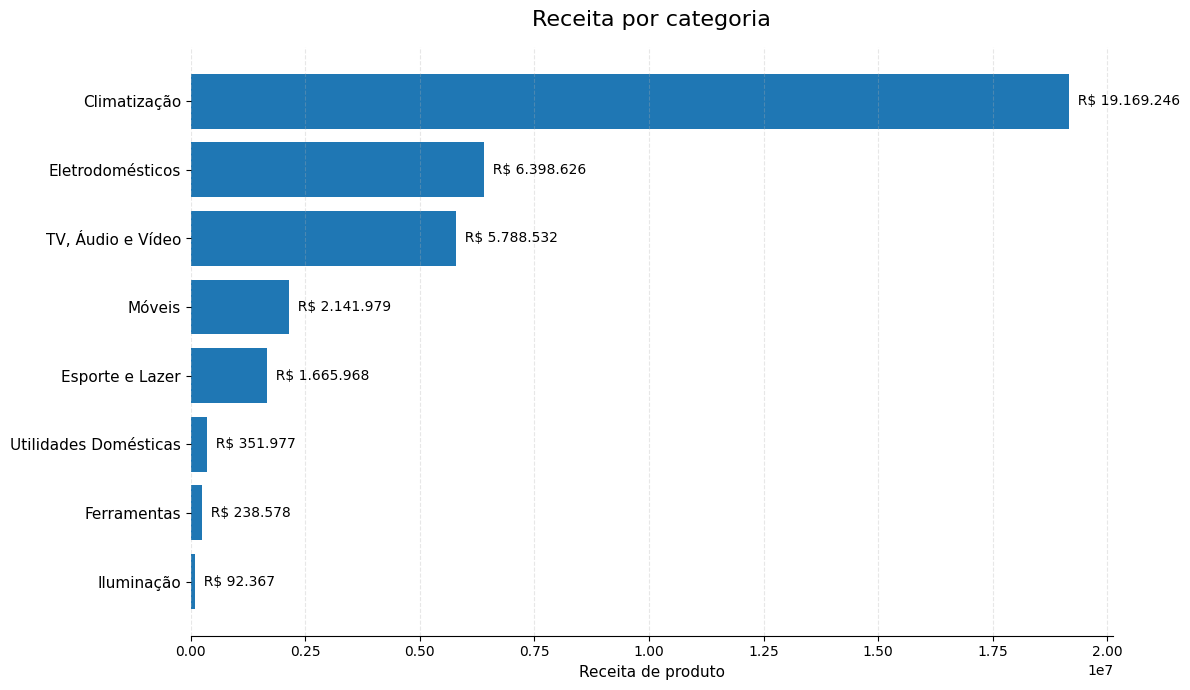

In [152]:
cat_plot = categorias_resumo.sort_values("receita_produto", ascending=True)

plt.figure(figsize=(12, 7))
barras = plt.barh(cat_plot["categoria"], cat_plot["receita_produto"])

plt.title("Receita por categoria", fontsize=16, pad=15)
plt.xlabel("Receita de produto", fontsize=11)
plt.ylabel("")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

for barra in barras:
    largura = barra.get_width()
    valor_formatado = f"R$ {largura:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")
    plt.text(
        largura,
        barra.get_y() + barra.get_height() / 2,
        f"  {valor_formatado}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### 3.5.7. Visualização da variação de receita por categoria

Para complementar a leitura da performance mensal, foi criado um gráfico com a variação percentual de receita entre janeiro e fevereiro por categoria. Essa visualização ajuda a identificar rapidamente quais frentes ganharam ou perderam tração no curto prazo.

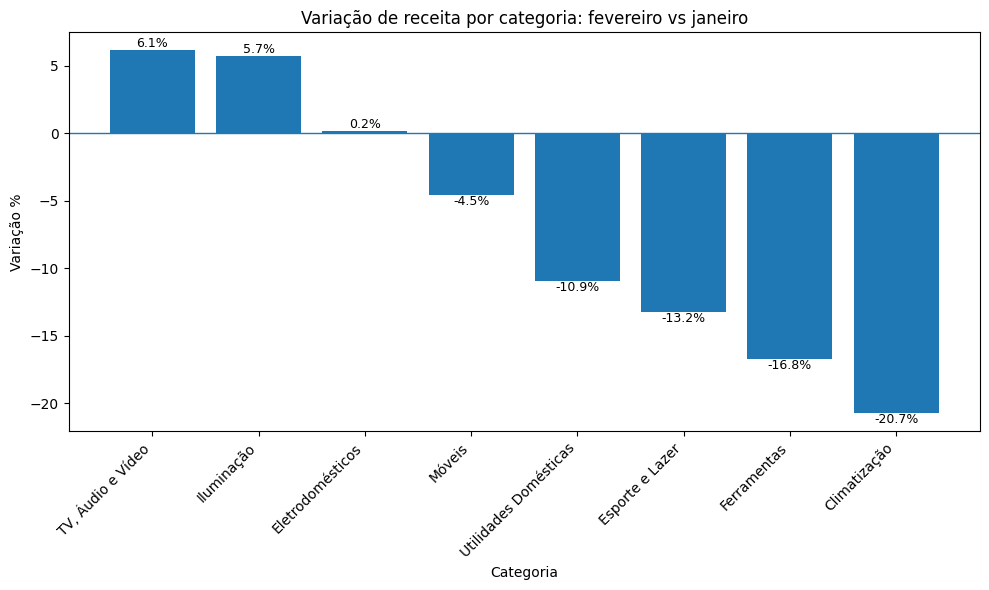

In [153]:
plot_var = categorias_jan_fev.sort_values("receita_produto_var_pct", ascending=False)

plt.figure(figsize=(10, 6))
barras = plt.bar(plot_var["categoria"], plot_var["receita_produto_var_pct"])

plt.xticks(rotation=45, ha="right")
plt.title("Variação de receita por categoria: fevereiro vs janeiro")
plt.ylabel("Variação %")
plt.xlabel("Categoria")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.1f}%",
        ha="center",
        va="bottom" if altura >= 0 else "top",
        fontsize=9
    )

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

O gráfico evidencia que a variação de receita entre janeiro e fevereiro não foi homogênea entre as categorias.

**TV, Áudio e Vídeo** aparece como o principal destaque positivo, com crescimento de receita no período, sugerindo melhora de mix ou aumento de ticket mesmo sem grande expansão de volume. **Eletrodomésticos** também se mostra relativamente estável, com leve avanço de receita.

No lado negativo, a queda mais relevante está em **Climatização**, principal categoria da operação, que perdeu receita de forma expressiva entre os dois meses. Como essa categoria concentra mais da metade do faturamento, sua retração tem impacto importante no resultado agregado.

Outras categorias, como **Esporte e Lazer** e **Ferramentas**, também apresentaram retração, embora com peso menor na receita total. Já categorias como **Iluminação** e **Utilidades Domésticas** têm participação mais baixa no resultado consolidado, então suas oscilações têm efeito mais limitado sobre o total da operação.

### 3.5.8. Análise de CRM por categoria

Além da leitura transacional, a base de CRM foi utilizada como contexto complementar para entender se determinadas categorias também estavam sendo estimuladas por campanhas de e-mail marketing.

O objetivo desta etapa é identificar:
- quais categorias receberam mais apoio de CRM;
- quais concentraram mais receita atribuída;
- e se existe alinhamento entre esforço de ativação e performance comercial.

In [154]:
crm_categoria = crm.groupby("categoria_foco").agg(
    campanhas=("nome_campanha", "count"),
    envios=("total_envios", "sum"),
    aberturas=("total_aberturas", "sum"),
    cliques=("total_cliques", "sum"),
    conversoes=("total_conversoes", "sum"),
    receita_atribuida=("receita_atribuida", "sum"),
    taxa_abertura_media=("taxa_abertura", "mean"),
    taxa_clique_media=("taxa_clique", "mean"),
    taxa_conversao_media=("taxa_conversao", "mean")
).reset_index()

crm_categoria = crm_categoria.sort_values("receita_atribuida", ascending=False)

display(crm_categoria)

crm_categoria.to_csv("crm_categoria_resumo.csv", index=False)

,categoria_foco,campanhas,envios,aberturas,cliques,conversoes,receita_atribuida,taxa_abertura_media,taxa_clique_media,taxa_conversao_media
0,Climatização,29,349094,95998,5593,35,33300.58,0.273514,0.055641,0.005776
1,Eletrodomésticos,24,284463,58582,2921,21,21433.31,0.210800,0.052737,0.007450
2,Esporte e Lazer,30,453142,96956,4877,30,10517.49,0.213683,0.047577,0.005327
4,Utilidades Domésticas,30,353051,81422,4541,31,9911.30,0.230493,0.052163,0.004687
3,"TV, Áudio e Vídeo",33,417597,101634,5768,26,6711.53,0.246082,0.054812,0.004006


A base de CRM mostra que **Climatização** e **Eletrodomésticos** concentram a maior receita atribuída entre as categorias analisadas, com **R\$ 33,3 mil** e **R$ 21,4 mil**, respectivamente. Isso indica que o esforço de CRM está mais alinhado às categorias que já têm maior peso comercial na operação.

**TV, Áudio e Vídeo**, apesar de ser uma das categorias mais relevantes em receita transacional, aparece com receita atribuída bem menor no CRM (**R$ 6,7 mil**), o que sugere uma presença relativamente mais fraca dessa categoria nas campanhas ou menor eficiência do canal nesse recorte.

Em volume de campanhas, **TV, Áudio e Vídeo**, **Esporte e Lazer** e **Utilidades Domésticas** aparecem com frequência semelhante ou superior às categorias líderes em receita atribuída, o que indica que maior esforço de disparo nem sempre se converte em maior resultado financeiro.

De forma geral, a leitura sugere que o CRM está reforçando principalmente categorias já fortes, mas ainda há espaço para avaliar se a distribuição do esforço está otimizada em relação ao retorno gerado por categoria.

### 3.5.9. Visualização da receita atribuída por categoria no CRM

Para complementar a análise de CRM, foi criado um gráfico com a receita atribuída por categoria foco. A visualização ajuda a comparar rapidamente quais frentes receberam maior retorno financeiro a partir das campanhas.

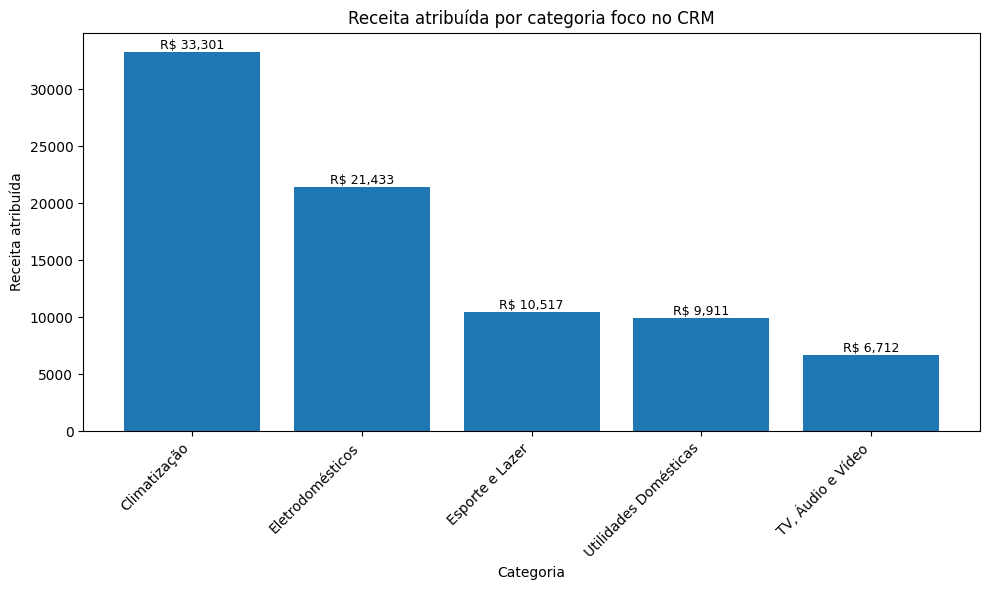

In [155]:
crm_plot = crm_categoria.sort_values("receita_atribuida", ascending=False)

plt.figure(figsize=(10, 6))
barras = plt.bar(crm_plot["categoria_foco"], crm_plot["receita_atribuida"])

plt.xticks(rotation=45, ha="right")
plt.title("Receita atribuída por categoria foco no CRM")
plt.ylabel("Receita atribuída")
plt.xlabel("Categoria")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"R$ {altura:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 3.6. Escopo analítico adotado

O case sugeria diferentes frentes exploratórias possíveis, como padrões temporais, marcas e taxa de conversão. Nesta entrega, optei por priorizar as análises mais diretamente conectadas às perguntas centrais do cliente: conciliação das bases, avaliação do banner, comportamento por categoria e reconciliação entre VTEX e GA4.

Essa escolha foi feita para privilegiar profundidade analítica, clareza metodológica e geração de insights acionáveis, em vez de ampliar excessivamente o escopo com leituras mais superficiais.

#4. Principais findings e insights

### 4.1. O banner não pode ser avaliado com segurança pela mensuração atual, e os sinais disponíveis não mostram ganho claro durante a exposição

A ausência de tracking de impressões e cliques no banner impede uma avaliação causal de sua efetividade. Com a estrutura atual, a análise só pode ser feita de forma inferencial, a partir do desempenho dos produtos expostos e da comparação com o restante da operação.

Os produtos que estiveram no banner apareceram em **111 pedidos** e geraram **R\$ 231.634,28** em receita de produto no período total. No entanto, apenas **23 pedidos** e **R\$ 54.885,59** ocorreram dentro da janela de exposição. Além disso, os produtos do banner representaram **0,65%** da receita da operação no período total e **0,46%** nas datas em que houve vendas dentro da janela.

**O que isso sugere:** com a mensuração disponível, não há evidência clara de que o banner esteja gerando incremento proporcional durante a exposição. O espaço pode estar funcionando mais como vitrine de produtos que já possuem demanda do que como alavanca claramente mensurável de resultado.

### 4.2. A operação é fortemente concentrada em poucas categorias, e a dinâmica mensal mostra sensibilidade relevante nessa concentração


**Climatização** concentra **53,5%** da receita total, seguida por **Eletrodomésticos** (**17,8%**) e **TV, Áudio e Vídeo** (**16,1%**). Essa distribuição mostra dependência relevante de poucas categorias, especialmente de frentes com ticket mais alto.

Na comparação entre janeiro e fevereiro, o comportamento não foi homogêneo. A principal categoria da operação, **Climatização**, apresentou queda de pedidos e receita, com ticket médio praticamente estável, sugerindo retração puxada por volume. Já **TV, Áudio e Vídeo** apresentou melhora de receita com volume mais estável, indicando possível ganho de mix ou ticket.

**O que isso sugere:** a empresa está exposta a oscilações importantes em poucas frentes principais, e isso deveria orientar tanto a priorização comercial quanto a leitura de performance por categoria.

### 4.3. O CRM parece reforçar principalmente categorias que já são fortes na operação

As maiores receitas atribuídas no CRM estão em **Climatização** (**R\$ 33.300,58**) e **Eletrodomésticos** (**R\$ 21.433,31**), enquanto **TV, Áudio e Vídeo**, mesmo sendo uma das categorias mais relevantes em receita transacional, aparece com retorno bem menor no canal.

**O que isso sugere:** o CRM parece estar sendo usado mais como reforço das categorias já fortes do que como ferramenta de aceleração de categorias com menor participação ou maior potencial de crescimento.

# 5. Recomendações priorizadas

### 5.1. Implementar tracking completo do banner no GA4


A principal recomendação é estruturar a mensuração do banner com eventos de **impressão** e **clique**, vinculando cada interação a atributos como **produto**, **posição** e **peça criativa**.

Hoje, a principal limitação da análise não está no volume de dados, mas na ausência de uma camada mínima de instrumentação que permita avaliar o banner com segurança. Sem essa mensuração, a empresa não consegue responder perguntas básicas como:
- quais produtos foram efetivamente vistos;
- quais receberam clique;
- quais posições performam melhor;
- e se existe diferença real entre exposição e resultado.

**Por que essa recomendação vem primeiro:** ela resolve a limitação estrutural mais importante do case. Sem essa evolução, qualquer análise sobre o banner continuará dependente de inferência e não permitirá otimização confiável do espaço.

### 5.2. Criar uma regra objetiva de seleção e priorização dos produtos exibidos no banner

A segunda recomendação é substituir a escolha manual ou pouco estruturada por uma lógica orientada por dados, considerando critérios como:
- performance histórica do produto;
- papel estratégico da categoria;
- ticket médio;
- objetivo comercial do período;
- e eventual suporte de CRM.

Os resultados atuais sugerem que o banner pode estar funcionando mais como vitrine de produtos que já têm demanda do que como alavanca clara de incremento. Por isso, o espaço da home deveria ser usado com uma lógica explícita de priorização, diferenciando, por exemplo:
- produtos para capturar demanda já existente;
- produtos para acelerar categorias estratégicas;
- e produtos para campanhas sazonais ou promocionais.

**Por que essa recomendação vem em segundo:** mesmo antes de ter a mensuração ideal, a empresa já pode melhorar a qualidade da decisão sobre o que destacar. Isso aumenta a chance de usar o banner de forma mais estratégica e mais alinhada ao objetivo de negócio.

#6. Limitações metodológicas

Esta análise apresenta limitações importantes que precisam ser consideradas na interpretação dos resultados.

## 6.1. O banner não possui tracking direto no GA4


A principal limitação do case é a ausência de eventos de impressão e clique para o banner da home. Isso impede uma avaliação causal da efetividade do espaço e limita a análise a uma abordagem inferencial, baseada no desempenho dos produtos expostos e no período em que estiveram no ar.

## 6.2. A planilha do banner foi preenchida manualmente e sem identificador do produto

Como a base enviada pelo cliente não continha `item_id`, foi necessário realizar uma etapa adicional de conciliação com o catálogo oficial. Embora a maior parte das linhas tenha sido conciliada com sucesso, parte do processo exigiu matching aproximado e uma validação manual complementar, o que adiciona um grau de incerteza metodológica.

## 6.3. Nem todos os produtos do banner puderam ser conciliados com o catálogo

Ao final da etapa de matching, **29 das 31 linhas** do banner foram conciliadas com o catálogo. As linhas restantes ficaram fora das análises que dependiam de vínculo direto com `item_id`, o que reduz parcialmente a cobertura da análise do banner.

## 6.4. A análise do banner não mede incrementalidade

Mesmo com a separação entre vendas totais e vendas dentro da janela de exposição, não é possível afirmar, com a estrutura atual, se o banner gerou incremento real de resultado ou se apenas destacou produtos que já teriam performance semelhante de forma orgânica.

## 6.5. A leitura de CRM é complementar, não causal

A base de CRM foi utilizada como contexto adicional para entender esforço de ativação e receita atribuída por categoria. No entanto, essa leitura não permite concluir isoladamente o impacto do canal sobre a performance transacional, especialmente sem uma modelagem de atribuição mais robusta.

# 7. Conclusão executiva

A análise mostra que o cliente já possui um volume relevante de dados, mas ainda enfrenta uma limitação estrutural importante para responder com segurança à principal pergunta do case: se o investimento no banner da home está valendo a pena.

Foi possível conciliar a maior parte dos produtos do banner com o catálogo e cruzá-los com a base transacional da VTEX, o que permitiu medir sua performance comercial. Os produtos expostos geraram vendas no período, mas a maior parte desse resultado não ocorreu dentro da janela de exposição, e a participação desses itens na receita da operação não aumentou de forma evidente durante esse recorte. Com a mensuração atual, portanto, não há evidência robusta de impacto incremental do banner.

Além disso, a operação se mostra fortemente concentrada em poucas categorias, com destaque para Climatização, Eletrodomésticos e TV, Áudio e Vídeo. O CRM, por sua vez, parece reforçar principalmente categorias que já são fortes na operação, o que sugere espaço para uma priorização mais estratégica do esforço de ativação.

Em termos práticos, as duas prioridades mais relevantes são: evoluir o tracking do banner no GA4, para permitir mensuração confiável de exposição e interação, e criar uma lógica objetiva de seleção dos produtos destacados na home. Sem essas duas frentes, o cliente continuará tomando decisões sobre um espaço nobre do site com baixa capacidade de avaliação e otimização.